In [ ]:
from datetime import date
print("PHÂN TÍCH VÀ DỰ BÁO NHU CẦU SỬ DỤNG DỊCH VỤ XE TAXI THEO THỜI GIAN, ĐỊA ĐIỂM VÀ THỜI TIẾT")
print("Date:", date.today())

PHÂN TÍCH VÀ DỰ BÁO NHU CẦU SỬ DỤNG DỊCH VỤ XE TAXI THEO THỜI GIAN, ĐỊA ĐIỂM VÀ THỜI TIẾT
Date: 2025-11-09


### GIAI ĐOẠN 1: CHUẨN BỊ DỮ LIỆU GỐC

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime
import re

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import geopandas as gpd
from shapely.geometry import Point

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, TimeSeriesSplit, GridSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, make_scorer
)
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor

import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib import cm


In [ ]:
# ĐỌC DỮ LIỆU
zones = gpd.read_file(r"E:\Kì 1 năm 3\Phân tích dữ liệu bằng Python\taxi_zones.shp")
train = pd.read_csv(r"E:\Kì 1 năm 3\Phân tích dữ liệu bằng Python\train.csv")
weather = pd.read_csv(r"E:\Kì 1 năm 3\Phân tích dữ liệu bằng Python\weather\weather_data_nyc_centralpark_2016(1).csv")

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [ ]:

# 1) Tạo GeoDataFrame cho điểm đón/trả và chuyển hệ tọa độ
pickup_points = gpd.GeoDataFrame(
    train,
    geometry=gpd.points_from_xy(train.pickup_longitude, train.pickup_latitude),
    crs="EPSG:4326"
).to_crs(zones.crs)

dropoff_points = gpd.GeoDataFrame(
    train,
    geometry=gpd.points_from_xy(train.dropoff_longitude, train.dropoff_latitude),
    crs="EPSG:4326"
).to_crs(zones.crs)

# 2) Spatial join: gán zone/borough cho từng điểm
# predicate="within": điểm nằm bên trong polygon nào thì nhận thuộc tính polygon đó
pickup_zone   = gpd.sjoin(pickup_points,  zones, how="left", predicate="within")
dropoff_zone  = gpd.sjoin(dropoff_points, zones, how="left", predicate="within")

# 3) Ghi kết quả join về bảng train
train["pickup_zone"]     = pickup_zone["zone"]        # tên zone nơi đón
train["pickup_borough"]  = pickup_zone["borough"]     # quận (borough) nơi đón
train["dropoff_zone"]    = dropoff_zone["zone"]       # tên zone nơi trả
train["dropoff_borough"] = dropoff_zone["borough"]    # quận (borough) nơi trả

# 4) Thống kê số chuyến theo zone
pickup_counts  = train.groupby("pickup_zone").size().reset_index(name="pickup_trips")
dropoff_counts = train.groupby("dropoff_zone").size().reset_index(name="dropoff_trips")

# 5) Gộp thống kê vào shapefile gốc để có bản đồ thematic
zones = zones.merge(pickup_counts,  left_on="zone", right_on="pickup_zone",  how="left")
zones = zones.merge(dropoff_counts, left_on="zone", right_on="dropoff_zone", how="left")

# điền 0 cho zone không có chuyến (NaN sau khi merge)
zones["pickup_trips"]  = zones["pickup_trips"].fillna(0)
zones["dropoff_trips"] = zones["dropoff_trips"].fillna(0)


In [ ]:
# 4. GHÉP DỮ LIỆU THỜI TIẾT
train["date"] = pd.to_datetime(train["pickup_datetime"], errors="coerce").dt.date
weather["date"] = pd.to_datetime(weather["date"], dayfirst=True).dt.date

train = pd.merge(train, weather, on="date", how="left")

In [ ]:
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_borough,dropoff_zone,dropoff_borough,date,maximum temperature,minimum temperature,average temperature,precipitation,snow fall,snow depth
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,Manhattan,Upper East Side South,Manhattan,2016-03-14,51,40,45.5,0.29,0.0,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,Manhattan,Greenwich Village South,Manhattan,2016-06-12,83,62,72.5,0.00,0.0,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,Manhattan,Seaport,Manhattan,2016-01-19,28,16,22.0,0.00,0.0,T
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,Manhattan,Financial District South,Manhattan,2016-04-06,48,30,39.0,0.00,0.0,0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,Manhattan,Upper West Side South,Manhattan,2016-03-26,55,38,46.5,0.00,0.0,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 22 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   id                   1458644 non-null  object 
 1   vendor_id            1458644 non-null  int64  
 2   pickup_datetime      1458644 non-null  object 
 3   dropoff_datetime     1458644 non-null  object 
 4   passenger_count      1458644 non-null  int64  
 5   pickup_longitude     1458644 non-null  float64
 6   pickup_latitude      1458644 non-null  float64
 7   dropoff_longitude    1458644 non-null  float64
 8   dropoff_latitude     1458644 non-null  float64
 9   store_and_fwd_flag   1458644 non-null  object 
 10  trip_duration        1458644 non-null  int64  
 11  pickup_zone          1457523 non-null  object 
 12  pickup_borough       1457523 non-null  object 
 13  dropoff_zone         1454900 non-null  object 
 14  dropoff_borough      1454900 non-null  object 
 15

In [ ]:
train.tail()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,pickup_borough,dropoff_zone,dropoff_borough,date,maximum temperature,minimum temperature,average temperature,precipitation,snow fall,snow depth
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,...,Manhattan,Flatiron,Manhattan,2016-04-08,50,40,45.0,0.01,0.0,0
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,...,Manhattan,Manhattan Valley,Manhattan,2016-01-10,59,40,49.5,1.80,0.0,0
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,...,Manhattan,Financial District North,Manhattan,2016-04-22,79,62,70.5,T,0.0,0
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,...,Manhattan,Midtown Center,Manhattan,2016-01-05,29,11,20.0,0.00,0.0,0
1458643,id1209952,1,2016-04-05 14:44:25,2016-04-05 14:47:43,1,-73.979538,40.781750,-73.972809,40.790585,N,...,Manhattan,Upper West Side North,Manhattan,2016-04-05,43,26,34.5,0.00,0.0,0


#### GIAI ĐOẠN 2: LÀM SẠCH DỮ LIỆU

In [ ]:
# Kiểm tra tổng số giá trị bị thiếu trong train
train.isna().sum().sum()

9730

In [ ]:
train = train.dropna()


In [ ]:
train.isna().sum().sort_values(ascending=False)


id                     0
vendor_id              0
snow fall              0
precipitation          0
average temperature    0
minimum temperature    0
maximum temperature    0
date                   0
dropoff_borough        0
dropoff_zone           0
pickup_borough         0
pickup_zone            0
trip_duration          0
store_and_fwd_flag     0
dropoff_latitude       0
dropoff_longitude      0
pickup_latitude        0
pickup_longitude       0
passenger_count        0
dropoff_datetime       0
pickup_datetime        0
snow depth             0
dtype: int64

In [ ]:
train.info

<bound method DataFrame.info of                 id  vendor_id      pickup_datetime     dropoff_datetime  \
0        id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1        id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2        id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3        id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4        id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   
...            ...        ...                  ...                  ...   
1458639  id2376096          2  2016-04-08 13:31:04  2016-04-08 13:44:02   
1458640  id1049543          1  2016-01-10 07:35:15  2016-01-10 07:46:10   
1458641  id2304944          2  2016-04-22 06:57:41  2016-04-22 07:10:25   
1458642  id2714485          1  2016-01-05 15:56:26  2016-01-05 16:02:39   
1458643  id1209952          1  2016-04-05 14:44:25  2016-04-05 14:47:43   

         passenger_count  pickup_longitude  pickup_latitude  \
0   

In [ ]:
train.dtypes


id                      object
vendor_id                int64
pickup_datetime         object
dropoff_datetime        object
passenger_count          int64
pickup_longitude       float64
pickup_latitude        float64
dropoff_longitude      float64
dropoff_latitude       float64
store_and_fwd_flag      object
trip_duration            int64
pickup_zone             object
pickup_borough          object
dropoff_zone            object
dropoff_borough         object
date                    object
maximum temperature      int64
minimum temperature      int64
average temperature    float64
precipitation           object
snow fall               object
snow depth              object
dtype: object

In [ ]:
# 1. CHUYỂN KIỂU DỮ LIỆU
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])
train['dropoff_datetime'] = pd.to_datetime(train['dropoff_datetime'])
train['vendor_id'] = train['vendor_id'].astype('category')
train['passenger_count'] = train['passenger_count'].astype('int')

In [ ]:
# Tính thời lượng thực tế tạm thời
time_diff = (train['dropoff_datetime'] - train['pickup_datetime']).dt.total_seconds()
# Kiểm tra tính nhất quán (không tạo cột mới)
check = np.abs(time_diff - train['trip_duration']) > 0
# Đếm số lượng
check_counts = check.value_counts().reset_index()
check_counts.columns = ['check', 'n']
print(check_counts)


   check        n
0  False  1454641


In [ ]:
# PHÁT HIỆN NGOẠI LAI VỀ THỜI GIAN VÀ VỊ TRÍ (DỰA VÀO RANH GIỚI NYC)
# Giới hạn biên hợp lý cho khu vực New York City
# (tương đối chính xác, bao gồm Manhattan, Brooklyn, Queens, Bronx, Staten Island)
lon_min, lon_max = -74.27, -73.68
lat_min, lat_max =  40.49,  40.92

# Xác định các chuyến có điểm đón hoặc trả nằm ngoài ranh giới này
too_far = train[
    (train["pickup_longitude"] < lon_min) | (train["pickup_longitude"] > lon_max) |
    (train["dropoff_longitude"] < lon_min) | (train["dropoff_longitude"] > lon_max) |
    (train["pickup_latitude"] < lat_min)  | (train["pickup_latitude"] > lat_max)  |
    (train["dropoff_latitude"] < lat_min) | (train["dropoff_latitude"] > lat_max)
]

# Ngoại lai thời gian
too_short = train[train["trip_duration"] < 10]
too_long  = train[train["trip_duration"] > 24 * 3600]

print(f"Số chuyến ngoài phạm vi New York City: {len(too_far)}")
print(f"Số chuyến quá ngắn (<10s): {len(too_short)}")
print(f"Số chuyến quá dài (>1 ngày): {len(too_long)}")


Số chuyến ngoài phạm vi New York City: 0
Số chuyến quá ngắn (<10s): 1878
Số chuyến quá dài (>1 ngày): 4


In [ ]:
# Xác định các chuyến đi có số khách hàng bé hơn 1 và lớn hơn 6
invalid_passengers = train[
    (train["passenger_count"] < 1) | (train["passenger_count"] > 6)
]

print(f"Số chuyến có passenger_count không hợp lệ: {len(invalid_passengers):,}")
print(invalid_passengers["passenger_count"].value_counts())


Số chuyến có passenger_count không hợp lệ: 55
passenger_count
0    55
Name: count, dtype: int64


In [ ]:
# Xử lý dữ liệu thời tiết
train['precipitation']   = pd.to_numeric(train['precipitation'].replace('T', 0.01), errors='coerce')
train['snow fall'] = pd.to_numeric(train['snow fall'].replace('T', 0.01), errors='coerce')
train['snow depth'] = pd.to_numeric(train['snow depth'].replace('T', 0.01), errors='coerce')
train['all_precip'] = train['snow fall'] + train['precipitation']
# Đổi tên cột nhiệt độ
train['max_temp'] = train['maximum temperature']
train['min_temp'] = train['minimum temperature']
train['avg_temp'] = train['average temperature']

In [ ]:
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,maximum temperature,minimum temperature,average temperature,precipitation,snow fall,snow depth,all_precip,max_temp,min_temp,avg_temp
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,51,40,45.5,0.29,0.0,0.00,0.29,51,40,45.5
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,83,62,72.5,0.00,0.0,0.00,0.00,83,62,72.5
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,28,16,22.0,0.00,0.0,0.01,0.00,28,16,22.0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,48,30,39.0,0.00,0.0,0.00,0.00,48,30,39.0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,55,38,46.5,0.00,0.0,0.00,0.00,55,38,46.5


In [ ]:
print(train.columns)


Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_zone', 'pickup_borough', 'dropoff_zone',
       'dropoff_borough', 'date', 'maximum temperature', 'minimum temperature',
       'average temperature', 'precipitation', 'snow fall', 'snow depth',
       'all_precip', 'max_temp', 'min_temp', 'avg_temp'],
      dtype='object')


#### GIAI ĐOẠN 3: PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)

##### Phân tích theo thời gian

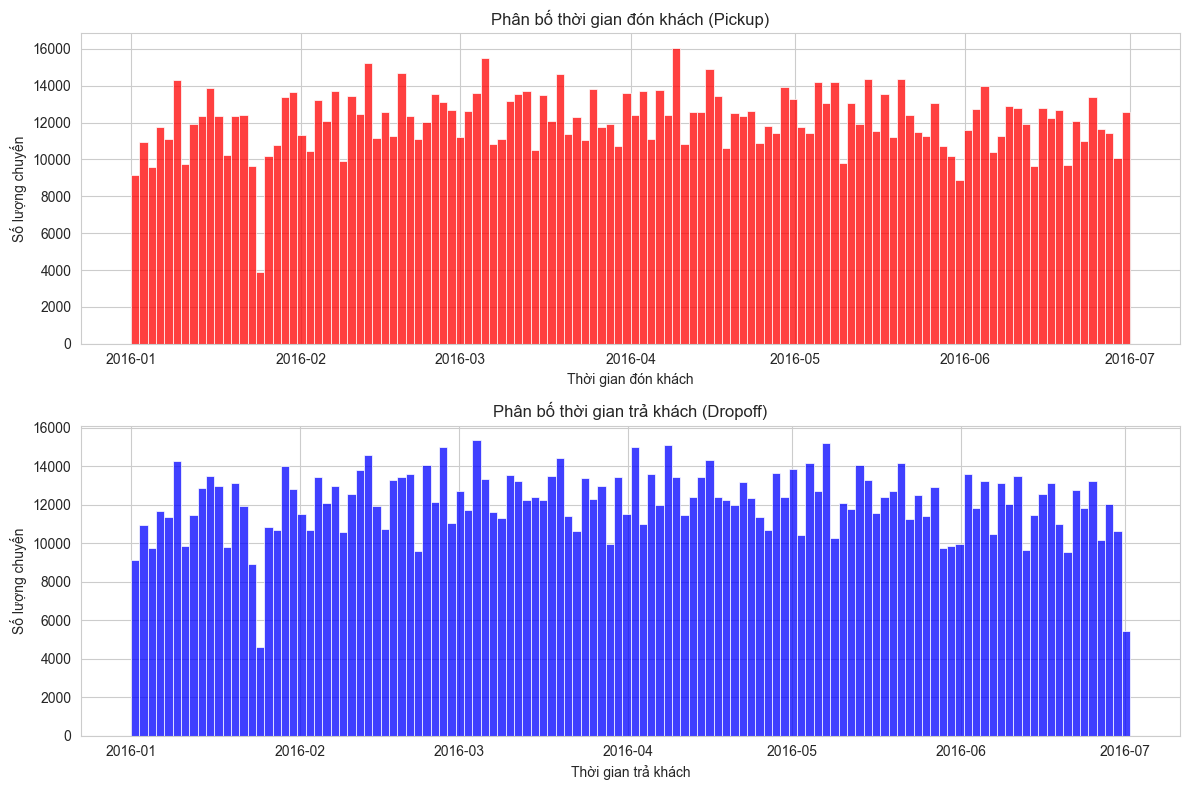

In [ ]:
# Phân bố thời gian đón và trả khách
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Phân bố thời gian đón khách
sns.histplot(train['pickup_datetime'], bins=120, color='red', ax=axes[0])
axes[0].set_title("Phân bố thời gian đón khách (Pickup)")
axes[0].set_xlabel("Thời gian đón khách")
axes[0].set_ylabel("Số lượng chuyến")

# Phân bố thời gian trả khách
sns.histplot(train['dropoff_datetime'], bins=120, color='blue', ax=axes[1])
axes[1].set_title("Phân bố thời gian trả khách (Dropoff)")
axes[1].set_xlabel("Thời gian trả khách")
axes[1].set_ylabel("Số lượng chuyến")

plt.tight_layout()
plt.show()


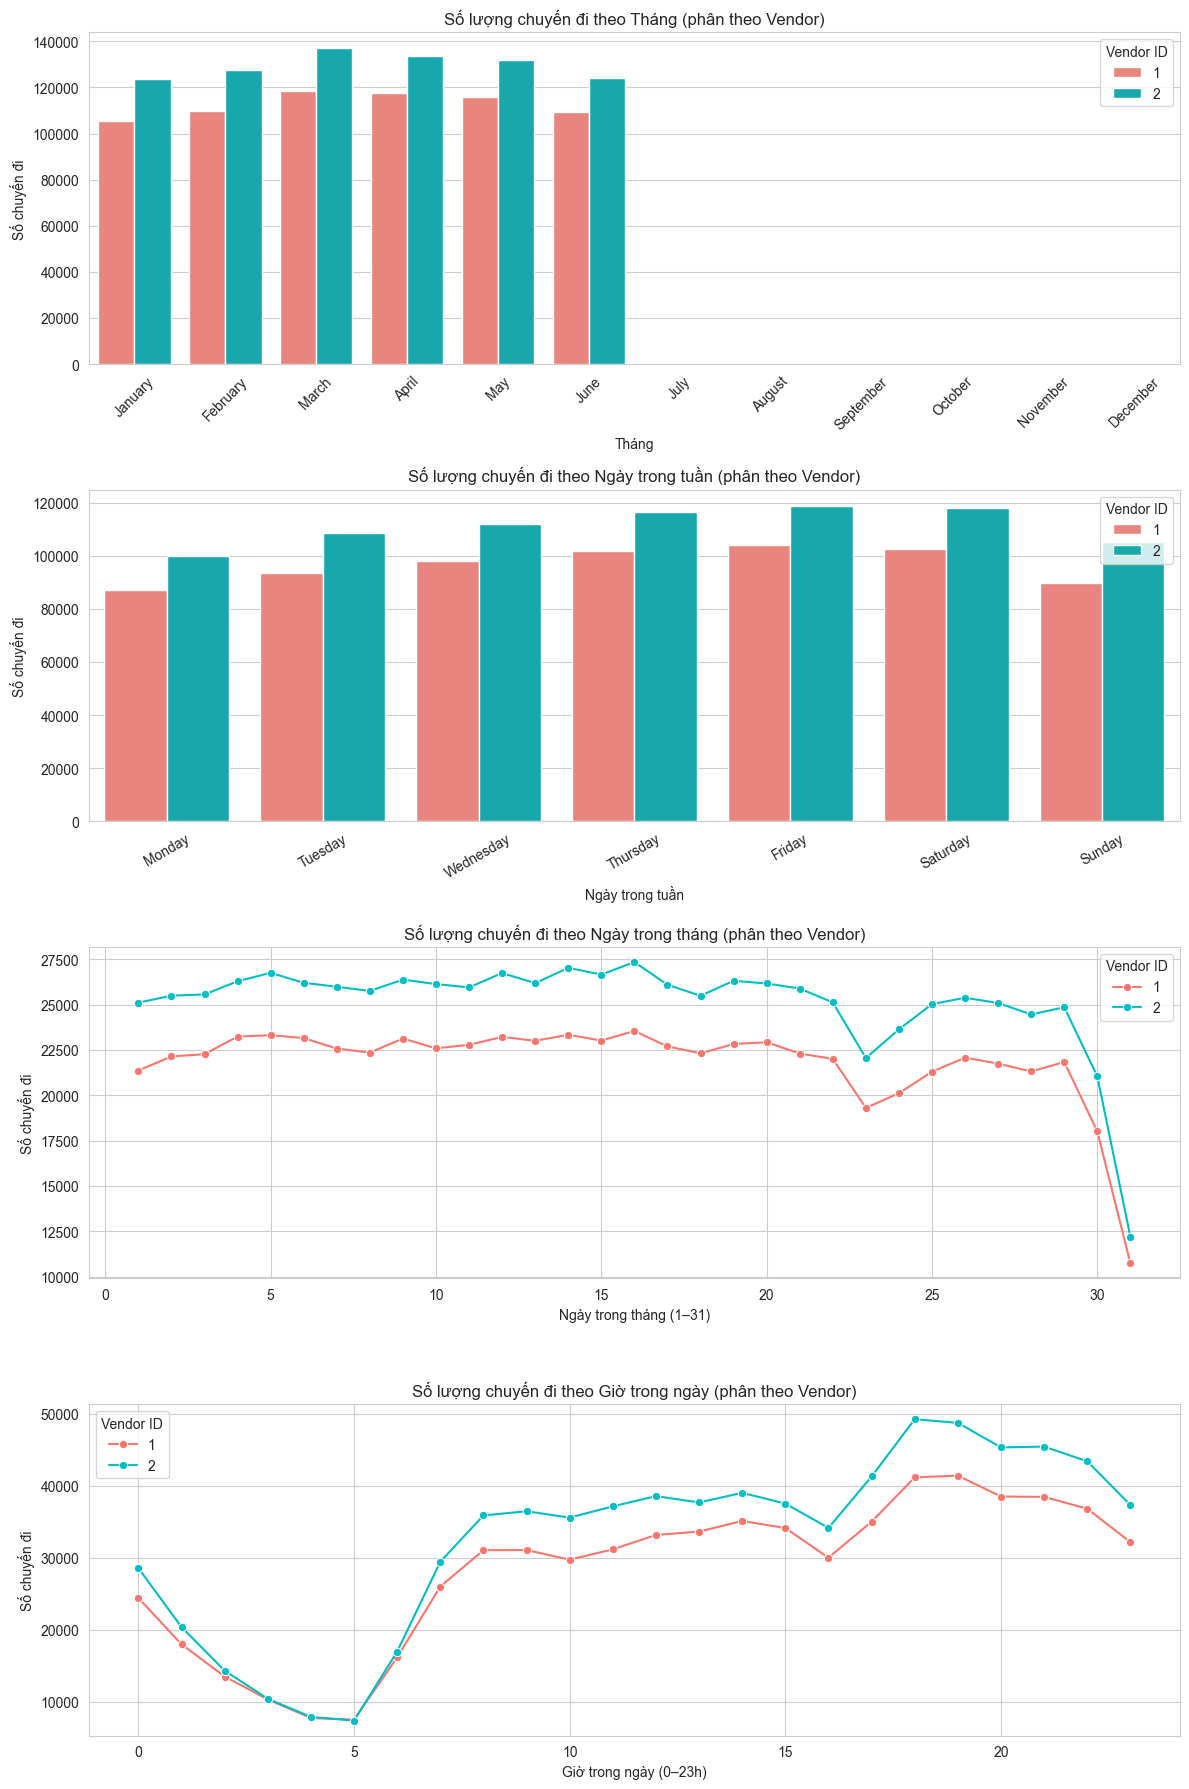

In [ ]:
sns.set_style("whitegrid")

# Tạo các cột thời gian
if not pd.api.types.is_datetime64_any_dtype(train["pickup_datetime"]):
    train["pickup_datetime"] = pd.to_datetime(train["pickup_datetime"], errors="coerce")

train['month'] = train['pickup_datetime'].dt.month_name()
train['weekday'] = train['pickup_datetime'].dt.day_name()
train['day'] = train['pickup_datetime'].dt.day
train['hour'] = train['pickup_datetime'].dt.hour

train['month'] = pd.Categorical(
    train['month'],
    categories=['January','February','March','April','May','June',
                'July','August','September','October','November','December'],
    ordered=True
)
train['weekday'] = pd.Categorical(
    train['weekday'],
    categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    ordered=True
)

# 2️ Tổng hợp số chuyến đi theo thời gian & vendor_id
month_count = (
    train.groupby(['month','vendor_id'], observed=False)
         .size().reset_index(name='trips')
)
weekday_count = (
    train.groupby(['weekday','vendor_id'], observed=False)
         .size().reset_index(name='trips')
)
day_count = (
    train.groupby(['day','vendor_id'], observed=False)
         .size().reset_index(name='trips')
)
hour_count = (
    train.groupby(['hour','vendor_id'], observed=False)
         .size().reset_index(name='trips')
)

# Vẽ biểu đồ
fig, axes = plt.subplots(4, 1, figsize=(12, 18))
vendor_palette = {1: "#F8766D", 2: "#00BFC4"}

# Theo tháng
sns.barplot(
    data=month_count, x='month', y='trips', hue='vendor_id',
    palette=vendor_palette, ax=axes[0]
)
axes[0].set_title("Số lượng chuyến đi theo Tháng (phân theo Vendor)")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Số chuyến đi")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Vendor ID")

# Theo ngày trong tuần
sns.barplot(
    data=weekday_count, x='weekday', y='trips', hue='vendor_id',
    palette=vendor_palette, ax=axes[1]
)
axes[1].set_title("Số lượng chuyến đi theo Ngày trong tuần (phân theo Vendor)")
axes[1].set_xlabel("Ngày trong tuần")
axes[1].set_ylabel("Số chuyến đi")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title="Vendor ID")

# Theo ngày trong tháng
sns.lineplot(
    data=day_count, x='day', y='trips', hue='vendor_id',
    palette=vendor_palette, marker='o', ax=axes[2]
)
axes[2].set_title("Số lượng chuyến đi theo Ngày trong tháng (phân theo Vendor)")
axes[2].set_xlabel("Ngày trong tháng (1–31)")
axes[2].set_ylabel("Số chuyến đi")
axes[2].legend(title="Vendor ID")

# Theo giờ trong ngày
sns.lineplot(
    data=hour_count, x='hour', y='trips', hue='vendor_id',
    palette=vendor_palette, marker='o', ax=axes[3]
)
axes[3].set_title("Số lượng chuyến đi theo Giờ trong ngày (phân theo Vendor)")
axes[3].set_xlabel("Giờ trong ngày (0–23h)")
axes[3].set_ylabel("Số chuyến đi")
axes[3].legend(title="Vendor ID")

plt.tight_layout()
plt.show()


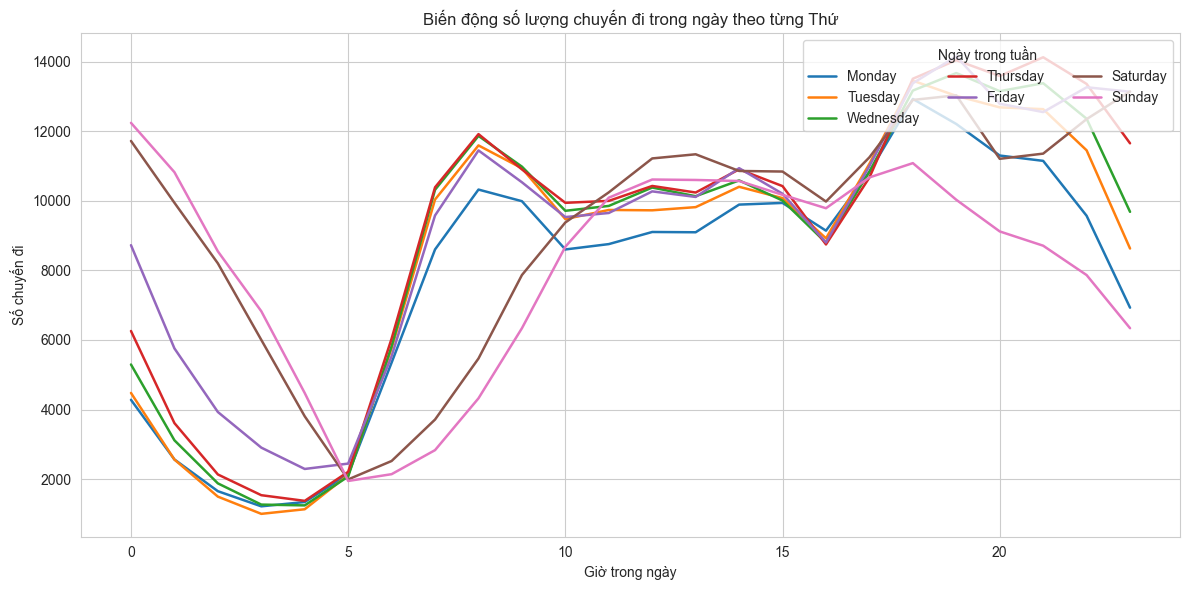

In [ ]:
# Quan sát biến động hàng ngày
hour_wday = (
    train.groupby(['weekday', 'hour'], observed=False)
    .size().reset_index(name='trips')
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_wday, x='hour', y='trips', hue='weekday', linewidth=1.8)
plt.title("Biến động số lượng chuyến đi trong ngày theo từng Thứ")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Số chuyến đi")
plt.legend(title="Ngày trong tuần", loc='upper right', ncol=3)
plt.tight_layout()
plt.show()


####  Phân tích Theo Địa điểm (Location)

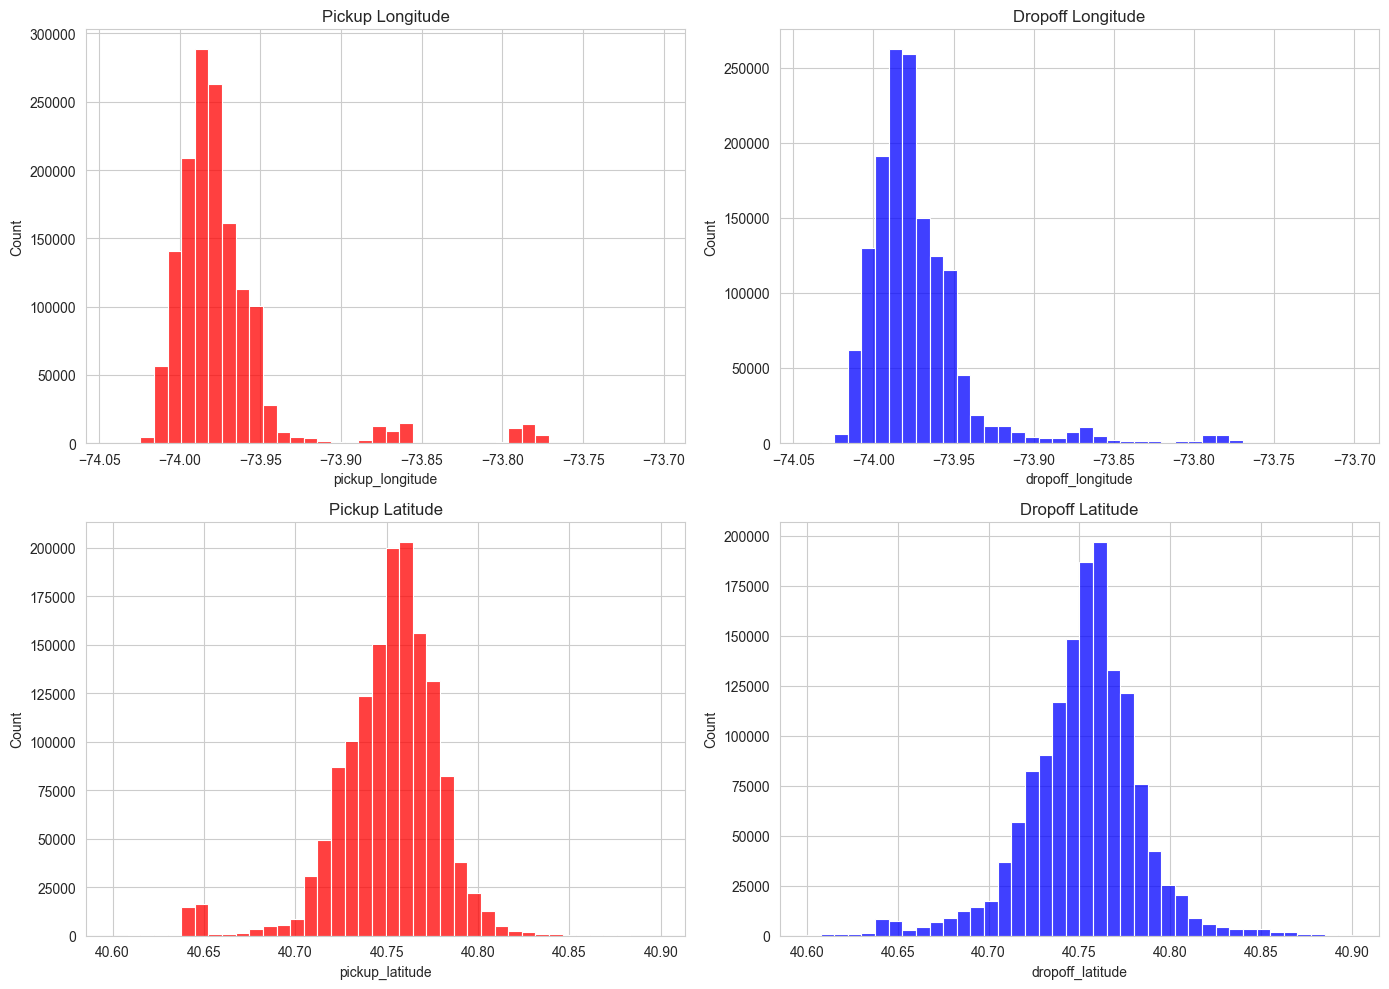

In [ ]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pickup Longitude
sns.histplot(
    data=train[(train['pickup_longitude'] > -74.05) & (train['pickup_longitude'] < -73.7)],
    x='pickup_longitude', bins=40, color='red', ax=axes[0, 0]
)
axes[0, 0].set_title('Pickup Longitude')

# Dropoff Longitude
sns.histplot(
    data=train[(train['dropoff_longitude'] > -74.05) & (train['dropoff_longitude'] < -73.7)],
    x='dropoff_longitude', bins=40, color='blue', ax=axes[0, 1]
)
axes[0, 1].set_title('Dropoff Longitude')

# Pickup Latitude
sns.histplot(
    data=train[(train['pickup_latitude'] > 40.6) & (train['pickup_latitude'] < 40.9)],
    x='pickup_latitude', bins=40, color='red', ax=axes[1, 0]
)
axes[1, 0].set_title('Pickup Latitude')

# Dropoff Latitude
sns.histplot(
    data=train[(train['dropoff_latitude'] > 40.6) & (train['dropoff_latitude'] < 40.9)],
    x='dropoff_latitude', bins=40, color='blue', ax=axes[1, 1]
)
axes[1, 1].set_title('Dropoff Latitude')

plt.tight_layout()
plt.show()


In [ ]:
import folium
from folium.plugins import MousePosition
# Vẽ bản đồ
m = folium.Map(location=[40.75, -73.98], zoom_start=11, tiles="CartoDB Positron")

folium.Choropleth(
    geo_data=zones,
    data=zones,
    columns=["zone", "pickup_trips"],
    key_on="feature.properties.zone",
    fill_color="YlGnBu",
    fill_opacity=0.8,
    line_opacity=0.3,
    name="Điểm đón (Pickup)",
    legend_name="Số lượng chuyến đón (YlGnBu)"
).add_to(m)

folium.Choropleth(
    geo_data=zones,
    data=zones,
    columns=["zone", "dropoff_trips"],
    key_on="feature.properties.zone",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.3,
    name="Điểm trả (Dropoff)",
    legend_name="Số lượng chuyến trả (YlOrRd)"
).add_to(m)

tooltip = folium.GeoJsonTooltip(
    fields=["zone", "borough", "pickup_trips", "dropoff_trips"],
    aliases=["Zone:", "Borough:", "Số chuyến đón:", "Số chuyến trả:"],
)
folium.GeoJson(
    zones,
    style_function=lambda x: {"color": "black", "weight": 0.3, "fillOpacity": 0},
    tooltip=tooltip,
    name="Chi tiết"
).add_to(m)

MousePosition().add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

m.save("nyc_trip_distribution_train.html")
print(" Đã tạo bản đồ từ dữ liệu train: nyc_trip_distribution_train.html")



 Đã tạo bản đồ từ dữ liệu train: nyc_trip_distribution_train.html


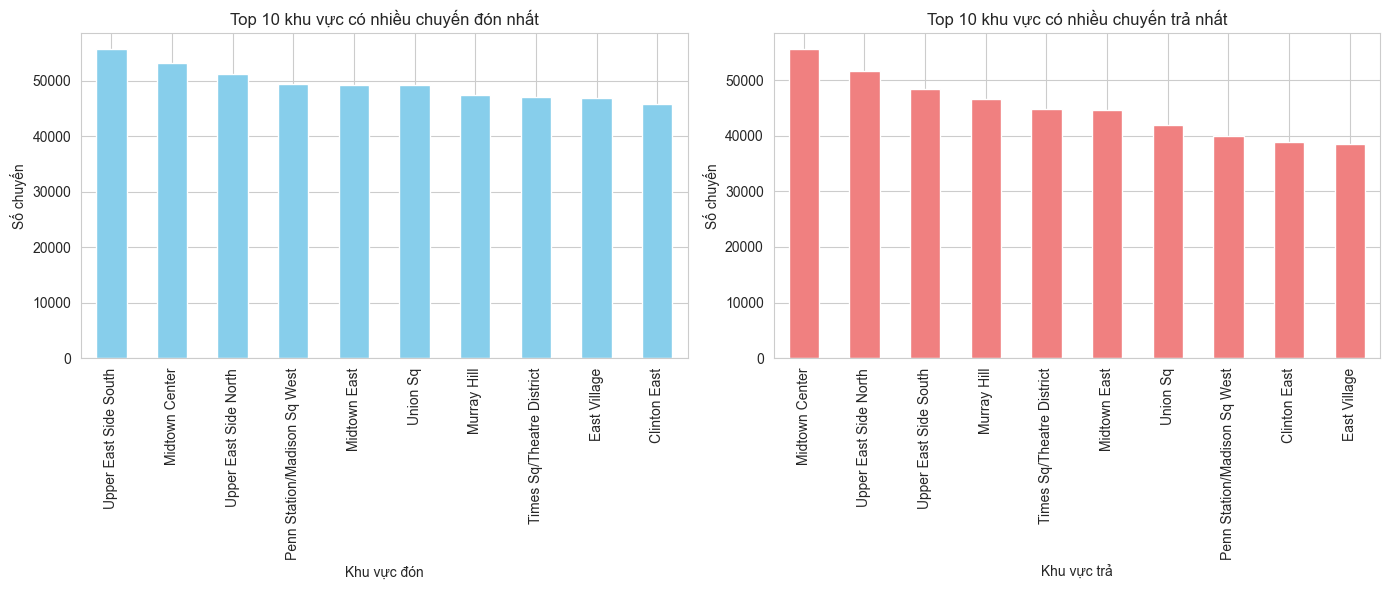

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pickup_zone_counts = train['pickup_zone'].value_counts().head(10)
dropoff_zone_counts = train['dropoff_zone'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pickup_zone_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 khu vực có nhiều chuyến đón nhất')
axes[0].set_xlabel('Khu vực đón')
axes[0].set_ylabel('Số chuyến')
axes[0].tick_params(axis='x', rotation=90)

dropoff_zone_counts.plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Top 10 khu vực có nhiều chuyến trả nhất')
axes[1].set_xlabel('Khu vực trả')
axes[1].set_ylabel('Số chuyến')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


#### Theo thời tiết

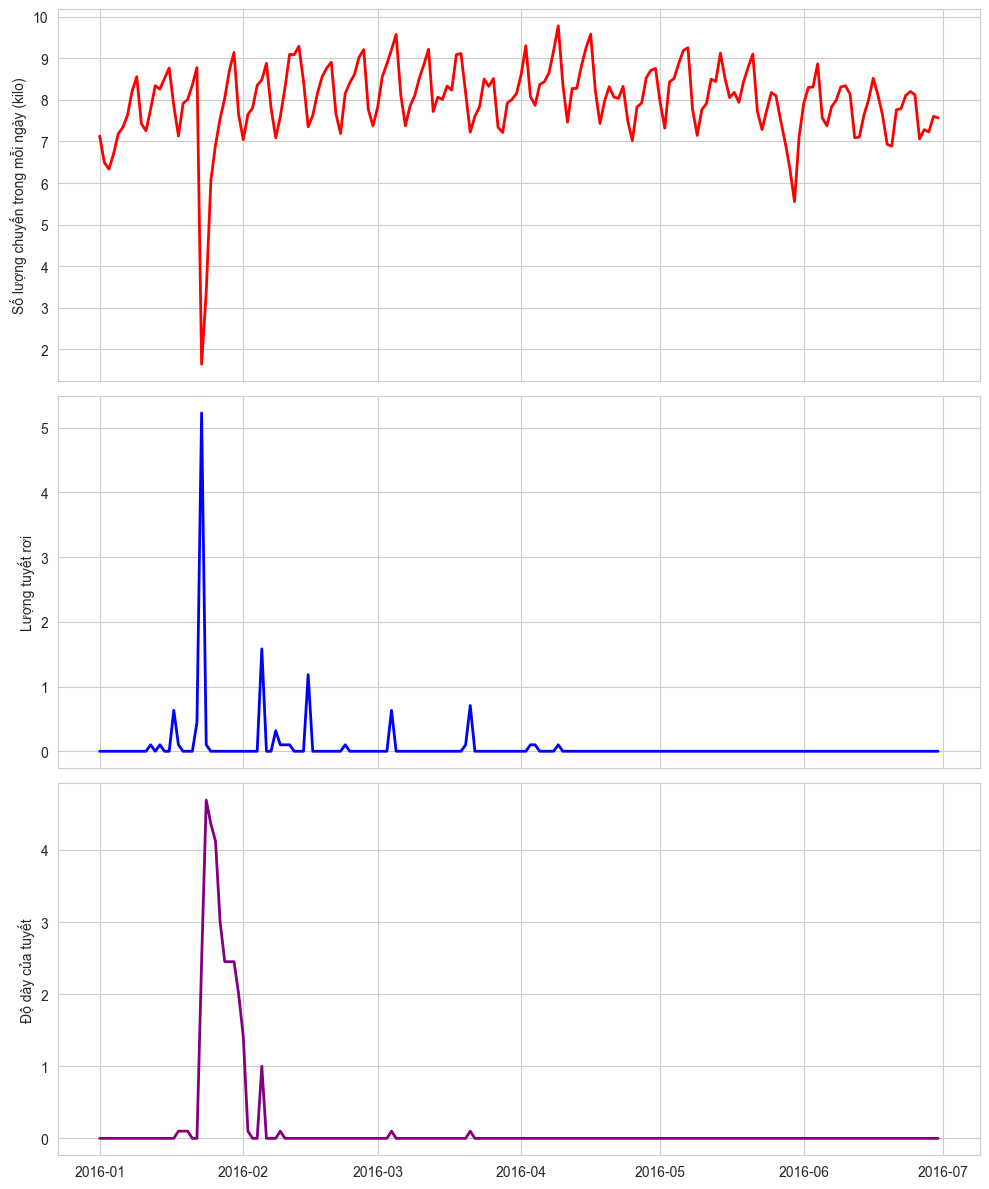

In [ ]:
train['date'] = pd.to_datetime(train['date'], errors='coerce')

p1 = train.groupby('date').size().reset_index(name='trips')
p1['kilo_trips'] = p1['trips'] / 1e3

p2 = (train.groupby('date')
      .agg(snow_fall=('snow fall', 'mean'),
           rain_fall=('precipitation', 'mean'),
           all_precip=('all_precip', 'mean'))
      .reset_index())

p3 = (train.groupby('date')
      .agg(snow_depth=('snow depth', 'mean'))
      .reset_index())


fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axes[0].plot(p1['date'], p1['kilo_trips'], color='red', linewidth=2)
axes[0].set_ylabel('Số lượng chuyến trong mỗi ngày (kilo)')

axes[1].plot(p2['date'], np.sqrt(p2['snow_fall']), color='blue', linewidth=2)
axes[1].set_ylabel('Lượng tuyết rơi')

axes[2].plot(p3['date'], np.sqrt(p3['snow_depth']), color='purple', linewidth=2)
axes[2].set_ylabel('Độ dày của tuyết')

plt.tight_layout()
plt.show()


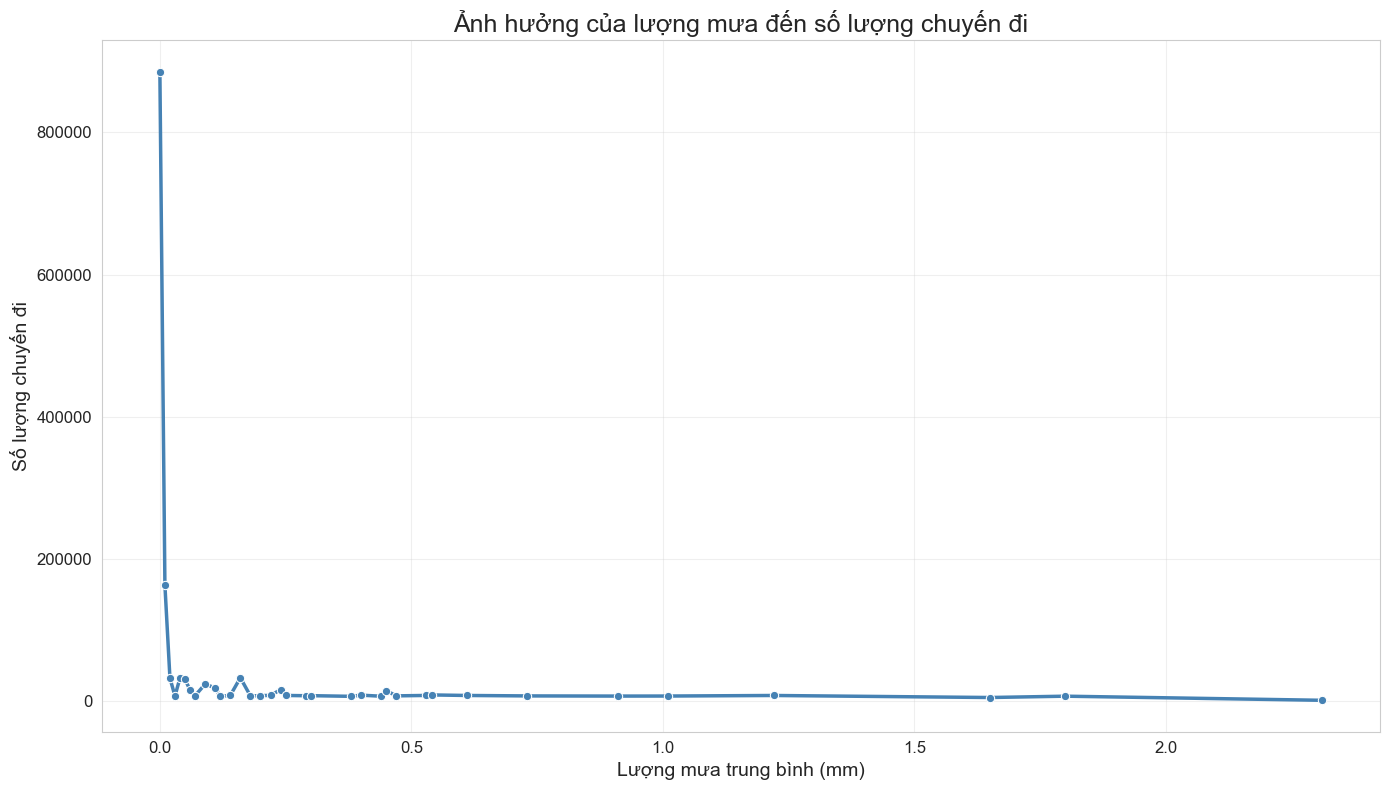

In [ ]:
rain_trips = (train.groupby('precipitation', as_index=False)
              .agg(trip_count=('id', 'count'))
              .sort_values('precipitation'))

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=rain_trips,
    x='precipitation',
    y='trip_count',
    marker='o',
    linewidth=2.5,
    color='steelblue'
)

plt.title("Ảnh hưởng của lượng mưa đến số lượng chuyến đi", fontsize=18)
plt.xlabel("Lượng mưa trung bình (mm)", fontsize=14)
plt.ylabel("Số lượng chuyến đi", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### GIAI ĐOẠN 4: KỸ THUẬT TÍNH NĂNG VÀ TỔNG HỢP (AGGREGATION & FEATURE ENGINEERING)


Tạo cột demand theo thời gian và theo thời gian + khu vực

In [ ]:
train["pickup_datetime"] = pd.to_datetime(train["pickup_datetime"], errors="coerce")
train["pickup_hour"] = train["pickup_datetime"].dt.floor("H")

# Tạo demand theo zone + thời gian
demand_1 = (
    train.groupby(["pickup_zone", "pickup_hour"])
         .size()
         .reset_index(name="demand_1")
)

# Tạo demand toàn theo thời gian
demand_2 = (
    train.groupby("pickup_hour")
         .size()
         .reset_index(name="demand_2")
)

Tạo các biến thời gian

In [ ]:
train["hour"] = train["pickup_hour"].dt.hour.astype("int8")
train["weekday"] = train["pickup_hour"].dt.weekday.astype("int8")
train["is_weekend"] = train["weekday"].isin([5,6]).astype("int8")
train["sin_hour"] = np.sin(2*np.pi*train["hour"]/24).astype("float32")
train["cos_hour"] = np.cos(2*np.pi*train["hour"]/24).astype("float32")



Tạo các biến không gian

In [ ]:
zones["centroid"] = zones.geometry.centroid
# Lấy kinh / vĩ độ từ centroid
zones["longitude"] = zones["centroid"].x.astype("float32")
zones["latitude"] = zones["centroid"].y.astype("float32")
zones_coords = zones[["zone", "borough", "longitude", "latitude"]] # Ghép vào train theo pickup_zone
train = train.merge( zones_coords, left_on="pickup_zone", right_on="zone", how="left" ).drop(columns=["zone"])

train["borough_id"] = LabelEncoder().fit_transform(train["borough"].astype(str)).astype("int16")
train["zone_id"] = LabelEncoder().fit_transform(train["pickup_zone"].astype(str)).astype("int32")

Tạo biến thời tiết

In [ ]:
train["all_precip"] = train["all_precip"].astype("float32")
train["has_rain"] = (train["precipitation"] > 0).astype("int8")
train["has_snow"] = ((train["snow fall"] > 0) | (train["snow depth"] > 0)).astype("int8")

train["is_blizzard"] = (
    (train["pickup_datetime"] >= "2016-01-22") &
    (train["pickup_datetime"] <= "2016-01-25")
).astype("int8")

train["is_blizzard_leadlag"] = (
    (train["pickup_datetime"] >= "2016-01-21") &
    (train["pickup_datetime"] <= "2016-01-27")
).astype("int8")


Trích xuất các đặc trưng cho mô hình truyền thống

In [ ]:
timeseries_cl = [
    "pickup_hour", "hour", "weekday", "day",
  "is_blizzard", "is_blizzard_leadlag", "all_precip"
]

train_subset = (
    train[timeseries_cl]
    .drop_duplicates(subset=["pickup_hour"])
    .reset_index(drop=True)
)

demand_ts = demand_2.merge(
    train_subset,
    on=["pickup_hour"],
    how="left"
)

print(f"demand_ts có {demand_ts.shape[0]:,} dòng, {demand_ts.shape[1]} cột")
print(demand_ts.head())

demand_ts có 4,359 dòng, 8 cột
          pickup_hour  demand_2  hour  weekday  day  is_blizzard  \
0 2016-01-01 00:00:00       543     0        4    1            0   
1 2016-01-01 01:00:00       561     1        4    1            0   
2 2016-01-01 02:00:00       500     2        4    1            0   
3 2016-01-01 03:00:00       477     3        4    1            0   
4 2016-01-01 04:00:00       318     4        4    1            0   

   is_blizzard_leadlag  all_precip  
0                    0         0.0  
1                    0         0.0  
2                    0         0.0  
3                    0         0.0  
4                    0         0.0  


Trích xuất các đặc trưng cho mô hình hiện đại

In [ ]:
ML_cl = [
    "pickup_zone", "pickup_hour",
    "hour", "sin_hour", "cos_hour",
    "all_precip", "has_rain", "has_snow",
    "is_blizzard", "is_blizzard_leadlag",
    "pickup_borough","zone_id", "borough_id",
    "longitude", "latitude","is_weekend"
]

train_subset = (
    train[ML_cl]
    .drop_duplicates(subset=["pickup_zone", "pickup_hour"])
    .reset_index(drop=True)
)

demand_ml = demand_1.merge(
    train_subset,
    on=["pickup_zone", "pickup_hour"],
    how="left"
)

print(f"demand_ml có {demand_ml.shape[0]:,} dòng, {demand_ml.shape[1]} cột")
print(demand_ml.head())

demand_ml có 247,859 dòng, 17 cột
               pickup_zone         pickup_hour  demand_1  hour  sin_hour  \
0  Allerton/Pelham Gardens 2016-02-17 21:00:00         1    21 -0.707107   
1  Allerton/Pelham Gardens 2016-04-16 01:00:00         1     1  0.258819   
2  Allerton/Pelham Gardens 2016-04-30 00:00:00         1     0  0.000000   
3  Allerton/Pelham Gardens 2016-06-05 06:00:00         1     6  1.000000   
4  Allerton/Pelham Gardens 2016-06-09 21:00:00         1    21 -0.707107   

       cos_hour  all_precip  has_rain  has_snow  is_blizzard  \
0  7.071068e-01        0.00         0         0            0   
1  9.659258e-01        0.00         0         0            0   
2  1.000000e+00        0.00         0         0            0   
3  6.123234e-17        0.91         1         0            0   
4  7.071068e-01        0.00         0         0            0   

   is_blizzard_leadlag pickup_borough  zone_id  borough_id    longitude  \
0                    0          Bronx        0   

## HUẤN LUYỆN MÔ HÌNH

MÔ HÌNH TRUYỀN THỐNG

CÁC YẾU TỐ ẢNH HƯỞNG ĐẾN SỰ BIẾN ĐỘNG CỦA CHUỖI THỜI GIAN

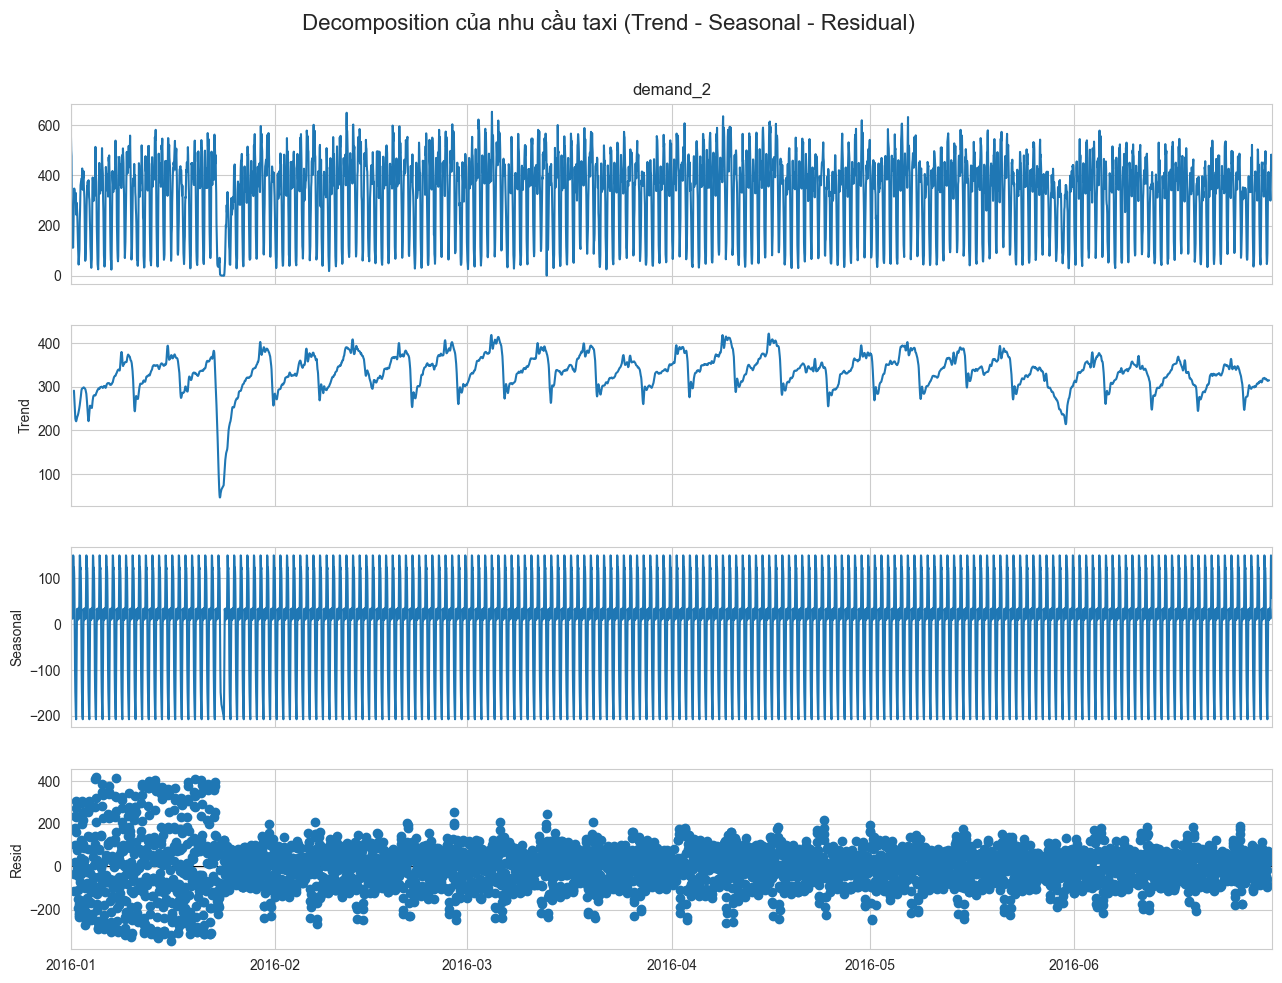

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

city_ts = (
    demand_ts.groupby("pickup_hour", as_index=True)["demand_2"]
             .sum()
             .sort_index()
)
city_ts.index = pd.to_datetime(city_ts.index)

result = seasonal_decompose(city_ts, model="additive", period=24)

fig = result.plot()
fig.set_size_inches(14, 10)
plt.suptitle(" Decomposition của nhu cầu taxi (Trend - Seasonal - Residual)", fontsize=16, y=1.02)
plt.show()


## SARIMAX

In [ ]:
ts = (
    demand_ts.set_index("pickup_hour")["demand_2"]
    .asfreq("H")
    .fillna(0)
)
print("Chuỗi thời gian đã tạo:", ts.shape)
print(ts.head())

Chuỗi thời gian đã tạo: (4368,)
pickup_hour
2016-01-01 00:00:00    543.0
2016-01-01 01:00:00    561.0
2016-01-01 02:00:00    500.0
2016-01-01 03:00:00    477.0
2016-01-01 04:00:00    318.0
Freq: h, Name: demand_2, dtype: float64


In [ ]:
def adf_test(x):
    res = adfuller(x, autolag="AIC")
    return {"ADF stat": res[0], "p-value": res[1]}

def kpss_test(x, regression="c"):
    stat, p, lags, *_ = kpss(x, regression=regression, nlags="auto")
    return {"KPSS stat": stat, "p-value": p, "lags": lags}

print("ADF test:", adf_test(ts))
print("KPSS test:", kpss_test(ts.values))

S = 24

ADF test: {'ADF stat': -7.783589948857782, 'p-value': 8.2922916888215e-12}
KPSS test: {'KPSS stat': 0.5174118147430463, 'p-value': 0.037745086769584164, 'lags': 21}


ADF test

H₀: Chuỗi không dừng

p-value = 8.29e-12 < 0.05 → bác bỏ H₀ → chuỗi DỪNG
Không cần sai phân xu hướng → d = 0

KPSS test

H₀: Chuỗi dừng

p-value = 0.0377 < 0.05 → bác bỏ H₀ → chuỗi KHÔNG dừng hoàn toàn
→ Cần sai phân mùa vụ → D = 1
Taxi có hành vi lặp lại hàng ngày (sáng đông, đêm ít) → còn dao động theo ngày.

Chu kỳ dữ liệu là 1 ngày = 24 giờ → S = 24

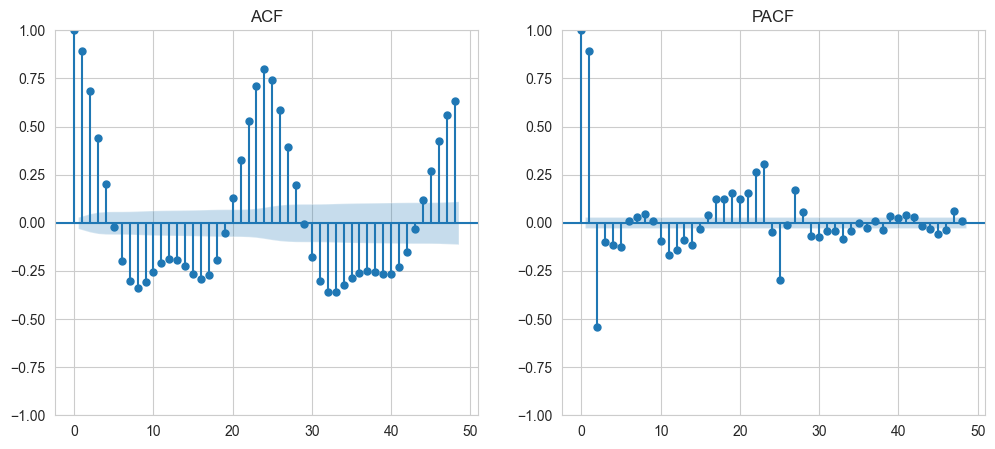

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_acf(ts, lags=48, ax=plt.gca())
plt.title("ACF")

plt.subplot(1,2,2)
plot_pacf(ts, lags=48, ax=plt.gca())
plt.title("PACF")
plt.show()


In [ ]:
exog_cols = ["all_precip", "is_blizzard", "is_blizzard_leadlag", "weekday"]

exog = (
    demand_ts.set_index("pickup_hour")[exog_cols]
    .sort_index()
    .asfreq("H")
    .fillna(0)
)

# Thêm lag_24h
exog["lag_24h"] = ts.shift(24).bfill()

# Làm sạch
exog = exog.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

In [ ]:
data = pd.concat([ts.rename("demand"), exog], axis=1).dropna()
y_full = data["demand"].astype(float)
X_full = data.drop(columns="demand").astype(float)

split_idx = int(len(y_full) * 0.8)
y_train, y_test = y_full.iloc[:split_idx], y_full.iloc[split_idx:]
X_train, X_test = X_full.iloc[:split_idx], X_full.iloc[split_idx:]

# Chuẩn hóa dữ liệu exog
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")

Train size: 3494 | Test size: 874


In [ ]:
model = SARIMAX(
    y_train,
    exog=X_train_sc,
    order=(2, 0, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("Tóm tắt mô hình SARIMAX:")
print(model.summary())


Tóm tắt mô hình SARIMAX:
                                      SARIMAX Results                                       
Dep. Variable:                               demand   No. Observations:                 3494
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 24)   Log Likelihood              -17796.121
Date:                              Sun, 09 Nov 2025   AIC                          35616.242
Time:                                      10:12:24   BIC                          35689.971
Sample:                                  01-01-2016   HQIC                         35642.577
                                       - 05-25-2016                                         
Covariance Type:                                opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
all_precip             -9.6505      0.886    -10.890   

In [ ]:
fc = model.get_forecast(steps=len(y_test), exog=X_test_sc)
y_pred = fc.predicted_mean
conf = fc.conf_int()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mean_y = y_test.mean()
mape = np.mean(np.abs((y_test - y_pred) / np.maximum(y_test, 10))) * 100
r2 = r2_score(y_test, y_pred)

print("\n Hiệu suất mô hình SARIMAX:")
print(f"MAE  = {mae:.2f} ({mae/mean_y*100:.2f}%)")
print(f"RMSE = {rmse:.2f} ({rmse/mean_y*100:.2f}%)")
print(f"MAPE = {mape:.2f}%")
print(f"R²   = {r2:.4f}")



 Hiệu suất mô hình SARIMAX:
MAE  = 57.33 (17.91%)
RMSE = 76.25 (23.82%)
MAPE = 28.06%
R²   = 0.6833


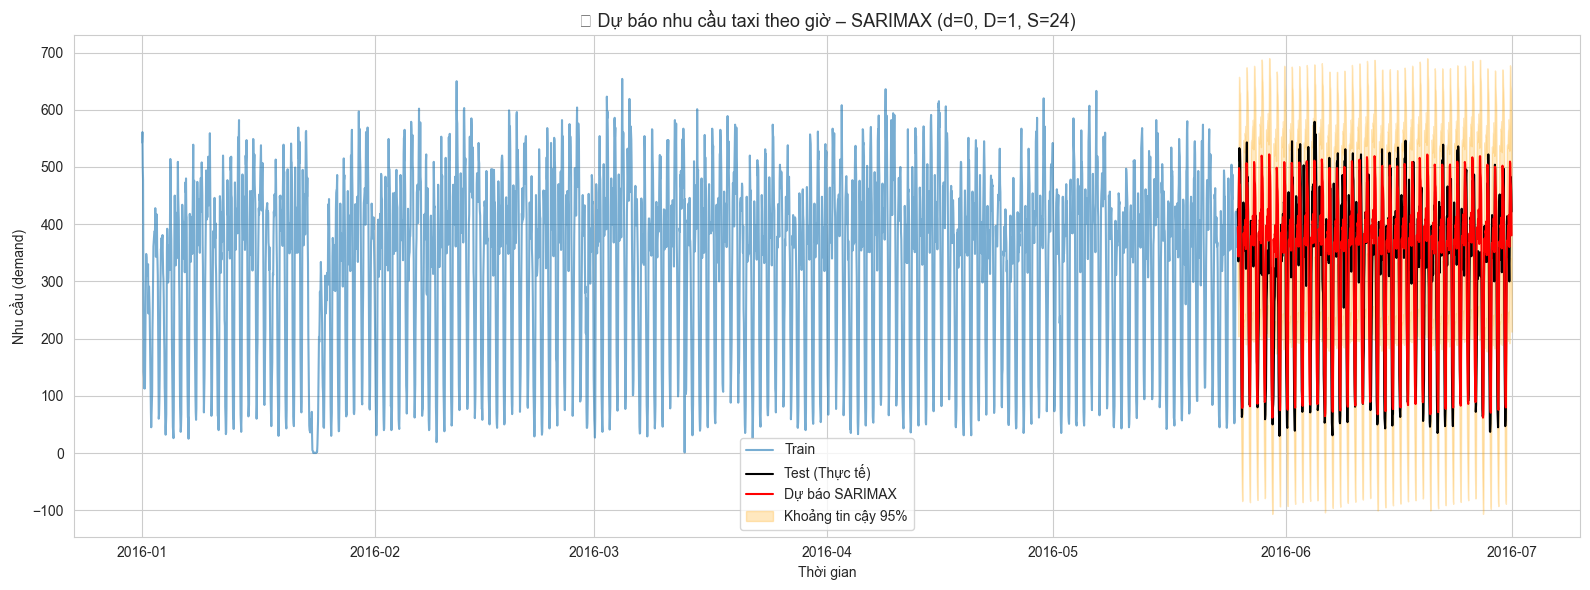

In [ ]:
plt.figure(figsize=(16, 6))
plt.plot(y_train.index, y_train, label="Train", color="tab:blue", alpha=0.6)
plt.plot(y_test.index,  y_test,  label="Test (Thực tế)", color="black")
plt.plot(y_pred.index, y_pred,  label="Dự báo SARIMAX", color="red")
plt.fill_between(y_pred.index, conf.iloc[:,0], conf.iloc[:,1],
                 alpha=0.25, color="orange", label="Khoảng tin cậy 95%")

plt.title("📈 Dự báo nhu cầu taxi theo giờ – SARIMAX (d=0, D=1, S=24)", fontsize=13)
plt.xlabel("Thời gian")
plt.ylabel("Nhu cầu (demand)")
plt.legend()
plt.tight_layout()
plt.show()

## PROPHET

In [ ]:
dfp = demand_ts.copy()
dfp = dfp.rename(columns={"pickup_hour": "ds", "demand_2": "y"})
dfp["ds"] = pd.to_datetime(dfp["ds"])
dfp = dfp.sort_values("ds").reset_index(drop=True)

# Biến ngoại sinh (giống SARIMAX)
regressors = ["all_precip", "is_blizzard", "is_blizzard_leadlag", "weekday"]

# Làm sạch NaN
for c in regressors:
    dfp[c] = pd.to_numeric(dfp[c], errors="coerce").fillna(0)

print(" Dữ liệu đầu vào Prophet:", dfp.shape)
print(dfp.head(3))

 Dữ liệu đầu vào Prophet: (4359, 8)
                   ds    y  hour  weekday  day  is_blizzard  \
0 2016-01-01 00:00:00  543     0        4    1            0   
1 2016-01-01 01:00:00  561     1        4    1            0   
2 2016-01-01 02:00:00  500     2        4    1            0   

   is_blizzard_leadlag  all_precip  
0                    0         0.0  
1                    0         0.0  
2                    0         0.0  


In [ ]:
split_idx = int(len(dfp) * 0.8)
train_df = dfp.iloc[:split_idx].copy()
test_df  = dfp.iloc[split_idx:].copy()

# Chuẩn hóa exog cho đồng nhất với SARIMAX
scaler = MinMaxScaler()
train_df[regressors] = scaler.fit_transform(train_df[regressors])
test_df[regressors]  = scaler.transform(test_df[regressors])

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")

Train rows: 3487 | Test rows: 872


In [ ]:
import random
from sklearn.metrics import mean_squared_error

# Không gian tham số để thử ngẫu nhiên
param_grid = {
    "changepoint_prior_scale": np.linspace(0.01, 0.2, 20),
    "seasonality_prior_scale": np.linspace(5, 30, 15),
    "seasonality_mode": ["additive", "multiplicative"],
    "fourier_daily": [10, 15, 20, 25, 30],
    "fourier_weekly": [5, 8, 10, 12, 15]
}

# Số lần thử
N_TRIALS = 15
results = []

for i in range(N_TRIALS):
    params = {
        "changepoint_prior_scale": float(random.choice(param_grid["changepoint_prior_scale"])),
        "seasonality_prior_scale": float(random.choice(param_grid["seasonality_prior_scale"])),
        "seasonality_mode": random.choice(param_grid["seasonality_mode"]),
        "fourier_daily": int(random.choice(param_grid["fourier_daily"])),
        "fourier_weekly": int(random.choice(param_grid["fourier_weekly"])),
    }

    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        seasonality_mode=params["seasonality_mode"],
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        changepoint_range=0.95,
        interval_width=0.9
    )

    m.add_seasonality('daily', period=1, fourier_order=params["fourier_daily"])
    m.add_seasonality('weekly', period=7, fourier_order=params["fourier_weekly"])

    for c in regressors:
        m.add_regressor(c)

    # Fit model
    m.fit(train_df[["ds", "y"] + regressors])

    # Dự báo
    fc = m.predict(test_df[["ds"] + regressors])
    rmse = np.sqrt(mean_squared_error(test_df["y"], fc["yhat"]))

    results.append((params, rmse))
    print(f"Trial {i+1}/{N_TRIALS}  RMSE={rmse:.2f} | {params}")

# Chọn bộ tham số tốt nhất
best_params, best_rmse = min(results, key=lambda x: x[1])

print("\n Best Prophet Parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  → Best RMSE = {best_rmse:.2f}")


10:12:26 - cmdstanpy - INFO - Chain [1] start processing
10:12:28 - cmdstanpy - INFO - Chain [1] done processing


Trial 1/15  RMSE=72.95 | {'changepoint_prior_scale': 0.19, 'seasonality_prior_scale': 30.0, 'seasonality_mode': 'additive', 'fourier_daily': 25, 'fourier_weekly': 5}


10:12:30 - cmdstanpy - INFO - Chain [1] start processing
10:12:31 - cmdstanpy - INFO - Chain [1] done processing


Trial 2/15  RMSE=66.67 | {'changepoint_prior_scale': 0.09999999999999999, 'seasonality_prior_scale': 21.071428571428573, 'seasonality_mode': 'additive', 'fourier_daily': 15, 'fourier_weekly': 10}


10:12:32 - cmdstanpy - INFO - Chain [1] start processing
10:12:34 - cmdstanpy - INFO - Chain [1] done processing


...

Trial 13/15  RMSE=65.98 | {'changepoint_prior_scale': 0.11, 'seasonality_prior_scale': 12.142857142857142, 'seasonality_mode': 'multiplicative', 'fourier_daily': 15, 'fourier_weekly': 10}


10:13:11 - cmdstanpy - INFO - Chain [1] start processing
10:13:12 - cmdstanpy - INFO - Chain [1] done processing


Trial 14/15  RMSE=67.40 | {'changepoint_prior_scale': 0.12, 'seasonality_prior_scale': 19.285714285714285, 'seasonality_mode': 'additive', 'fourier_daily': 15, 'fourier_weekly': 8}


10:13:14 - cmdstanpy - INFO - Chain [1] start processing
10:13:15 - cmdstanpy - INFO - Chain [1] done processing


Trial 15/15  RMSE=65.10 | {'changepoint_prior_scale': 0.04, 'seasonality_prior_scale': 30.0, 'seasonality_mode': 'multiplicative', 'fourier_daily': 10, 'fourier_weekly': 12}

 Best Prophet Parameters:
  changepoint_prior_scale: 0.17
  seasonality_prior_scale: 17.5
  seasonality_mode: additive
  fourier_daily: 20
  fourier_weekly: 15
  → Best RMSE = 52.31


In [ ]:
m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    seasonality_mode=best_params["seasonality_mode"],
    changepoint_prior_scale=best_params["changepoint_prior_scale"],
    seasonality_prior_scale=best_params["seasonality_prior_scale"],
    changepoint_range=0.95,
    interval_width=0.9
)

m.add_seasonality('daily',  period=1,  fourier_order=best_params["fourier_daily"])
m.add_seasonality('weekly', period=7,  fourier_order=best_params["fourier_weekly"])

for c in regressors:
    m.add_regressor(c)

m.fit(train_df[["ds", "y"] + regressors])


10:13:18 - cmdstanpy - INFO - Chain [1] start processing
10:13:20 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = test_df[["ds"] + regressors].copy()
forecast = m.predict(future)

eval_df = test_df[["ds", "y"]].merge(
    forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds", how="left"
)

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    denom  = np.where(y_true == 0, np.nan, y_true)
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0)

mae = mean_absolute_error(eval_df["y"], eval_df["yhat"])
rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["yhat"]))
r2 = r2_score(eval_df["y"], eval_df["yhat"])
mape = safe_mape(eval_df["y"], eval_df["yhat"])
mean_y = eval_df["y"].mean()

print("\n Hiệu suất mô hình Prophet:")
print(f"MAE  = {mae:.2f} ")
print(f"RMSE = {rmse:.2f} ")
print(f"MAPE = {mape:.2f}% | R² = {r2:.3f} ")



 Hiệu suất mô hình Prophet:
MAE  = 38.24 
RMSE = 52.31 
MAPE = 14.53% | R² = 0.851 


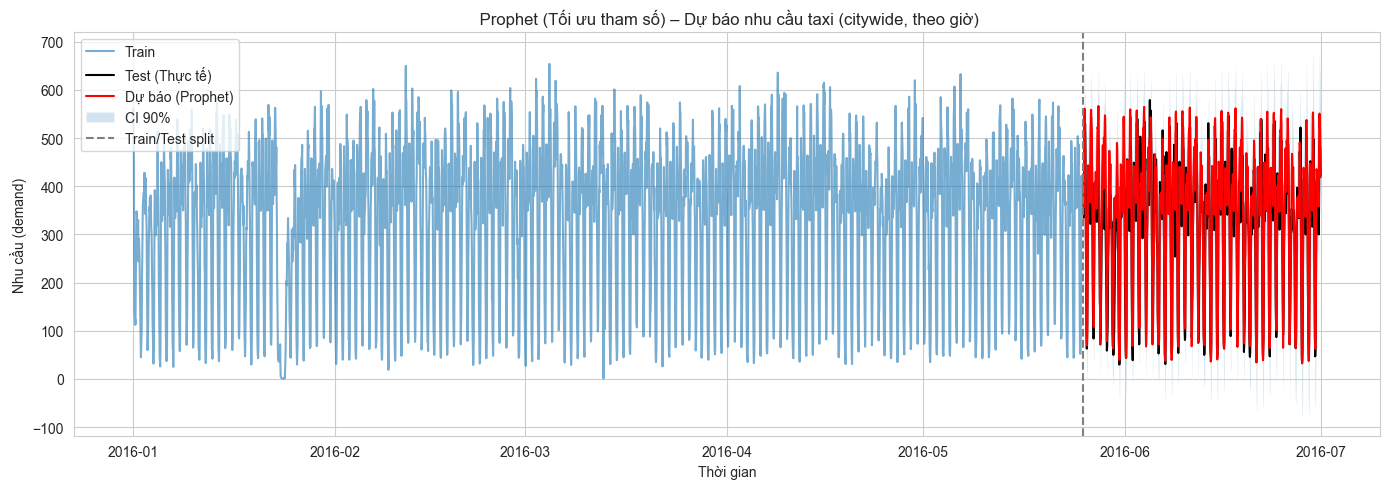

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(train_df["ds"], train_df["y"], label="Train", color="tab:blue", alpha=0.6)
plt.plot(test_df["ds"], test_df["y"], label="Test (Thực tế)", color="black")
plt.plot(eval_df["ds"], eval_df["yhat"], label="Dự báo (Prophet)", color="red")
plt.fill_between(eval_df["ds"], eval_df["yhat_lower"], eval_df["yhat_upper"],
                 alpha=0.2, label="CI 90%")
plt.axvline(train_df["ds"].iloc[-1], color="gray", linestyle="--", label="Train/Test split")
plt.title(" Prophet (Tối ưu tham số) – Dự báo nhu cầu taxi (citywide, theo giờ)")
plt.xlabel("Thời gian"); plt.ylabel("Nhu cầu (demand)")
plt.legend(); plt.tight_layout(); plt.show()

## MÔ HÌNH HIỆN ĐẠI

## Random forest

Dữ liệu đầu vào

In [ ]:
df = demand_ml.copy()
df = df.sort_values(["pickup_zone", "pickup_hour"]).reset_index(drop=True)

print(" Dữ liệu đầu vào:", df.shape)

 Dữ liệu đầu vào: (247859, 17)


In [ ]:
df = df.sort_values("pickup_hour").reset_index(drop=True)
split_time = df["pickup_hour"].quantile(0.8)

train_df = df[df["pickup_hour"] <= split_time].copy()
test_df  = df[df["pickup_hour"] >  split_time].copy()

print(f"Train đến: {train_df['pickup_hour'].max()} | Test từ: {test_df['pickup_hour'].min()}")
print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")

Train đến: 2016-05-25 23:00:00 | Test từ: 2016-05-26 00:00:00
Train: 198,353 | Test: 49,506


Tạo các feature lag và rolling

In [ ]:
train_df = train_df.sort_values(["pickup_zone", "pickup_hour"])
train_df["lag_1h"]  = train_df.groupby("pickup_zone")["demand_1"].shift(1)
train_df["lag_2h"]  = train_df.groupby("pickup_zone")["demand_1"].shift(2)
train_df["lag_24h"] = train_df.groupby("pickup_zone")["demand_1"].shift(24)

train_df["roll_mean_3h"]   = train_df.groupby("pickup_zone")["demand_1"].shift(1).rolling(3).mean()
train_df["roll_mean_24h"]  = train_df.groupby("pickup_zone")["demand_1"].shift(1).rolling(24).mean()
train_df["roll_mean_72h"]  = train_df.groupby("pickup_zone")["demand_1"].shift(1).rolling(72).mean()
train_df["roll_mean_168h"] = train_df.groupby("pickup_zone")["demand_1"].shift(1).rolling(168).mean()

lag_cols = ["lag_1h", "lag_2h", "lag_24h", "roll_mean_3h", "roll_mean_24h", "roll_mean_72h", "roll_mean_168h"]
train_df[lag_cols] = train_df[lag_cols].fillna(0).astype("float32")

test_df = test_df.sort_values(["pickup_zone", "pickup_hour"]).copy()
test_df[lag_cols] = np.nan

global_mean = train_df["demand_1"].mean()

for z, test_z in test_df.groupby("pickup_zone"):
    tr_z = train_df[train_df["pickup_zone"] == z].sort_values("pickup_hour")
    tz = test_z.copy()

    zone_mean = tr_z["demand_1"].mean() if len(tr_z) > 0 else global_mean
    last_24   = tr_z["demand_1"].tail(24)
    lag24_val = last_24.mean() if len(last_24) > 0 else zone_mean

    tz["lag_1h"]  = tz["demand_1"].shift(1)
    tz["lag_2h"]  = tz["demand_1"].shift(2)
    tz["lag_24h"] = lag24_val

    tz["roll_mean_3h"]   = tz["demand_1"].rolling(3).mean().fillna(zone_mean)
    tz["roll_mean_24h"]  = tz["demand_1"].rolling(24).mean().fillna(zone_mean)
    tz["roll_mean_72h"]  = tz["demand_1"].rolling(72).mean().fillna(zone_mean)
    tz["roll_mean_168h"] = tz["demand_1"].rolling(168).mean().fillna(zone_mean)

    test_df.loc[tz.index, lag_cols] = tz[lag_cols]

test_df = test_df.dropna(subset=["lag_1h", "lag_2h"]).reset_index(drop=True)
test_df[lag_cols] = test_df[lag_cols].astype("float32")

for df_ in [train_df, test_df]:
    df_["hour_peak"] = df_["hour"].isin([7,8,9,17,18,19]).astype(int)
    df_["rain_x_peak"] = df_["all_precip"] * df_["hour_peak"]
    df_["snow_x_weekend"] = df_["has_snow"] * df_["is_weekend"]
    df_["blizzard_x_precip"] = df_["is_blizzard"] * df_["all_precip"]

print(" Đã tạo lag/rolling & feature tương tác cho train/test thành công!")


 Đã tạo lag/rolling & feature tương tác cho train/test thành công!


Chọn features

In [ ]:
features = [
    "zone_id", "borough_id",
    "hour", "sin_hour", "cos_hour",
    "all_precip", "has_rain", "has_snow",
    "is_blizzard", "is_blizzard_leadlag",
    "lag_1h","lag_2h","lag_24h",
    "roll_mean_3h","roll_mean_24h","roll_mean_72h","roll_mean_168h",
    "longitude","latitude", "hour_peak","rain_x_peak","snow_x_weekend","blizzard_x_precip"
]
target = "demand_1"

X_train, y_train = train_df[features], train_df[target].astype("float32")
X_test,  y_test  = test_df[features],  test_df[target].astype("float32")

print(f"Feature shape: {X_train.shape} | Test: {X_test.shape}")

Feature shape: (198353, 23) | Test: (49085, 23)


In [ ]:
X_train_rf, y_train_rf = X_train.copy(), y_train.copy()
X_test_rf,  y_test_rf  = X_test.copy(),  y_test.copy()

print(f"Train size: {len(X_train_rf):,} | Test size: {len(X_test_rf):,}")

Train size: 198,353 | Test size: 49,085


Chọn siêu tham số bằng Random Search

In [ ]:
def mape_eps(y_true, y_pred, eps=10.0):
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom))

mape_scorer = make_scorer(lambda yt, yp: -mape_eps(yt, yp), greater_is_better=False)

rf = RandomForestRegressor(
    criterion="poisson",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

param_space = {
    "n_estimators": [100, 150, 200],
    "max_depth": [12, 16, 20],
    "min_samples_split": [4, 6, 8],
    "min_samples_leaf": [2, 4, 6],
    "max_features": [0.6, 0.8, 1.0],
    "max_samples": [0.7, 0.8, 0.9]
}

tscv = TimeSeriesSplit(n_splits=3)

rs = RandomizedSearchCV(
    rf,
    param_distributions=param_space,
    n_iter=10,
    cv=tscv,
    scoring=mape_scorer,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Đang chạy Random Search cho Random Forest")
rs.fit(X_train_rf, y_train_rf)

print("\n Best Params (Random Forest):", rs.best_params_)
best_model = rs.best_estimator_

Đang chạy Random Search cho Random Forest
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Best Params (Random Forest): {'n_estimators': 100, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_samples': 0.9, 'max_features': 1.0, 'max_depth': 16}


Dự báo và đánh giá mô hình

In [ ]:
y_pred_rf = best_model.predict(X_test_rf)


mae = mean_absolute_error(y_test_rf, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2 = r2_score(y_test_rf, y_pred_rf)
mape = mape_eps(y_test_rf, y_pred_rf) * 100

print("\n HIỆU NĂNG MÔ HÌNH Random Forest")
print(f"MAE   : {mae:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"R²    : {r2:.3f}")
print(f"MAPE  : {mape:.2f}%")


 HIỆU NĂNG MÔ HÌNH Random Forest
MAE   : 1.79
RMSE  : 2.64
R²    : 0.750
MAPE  : 15.87%


Feature Importance

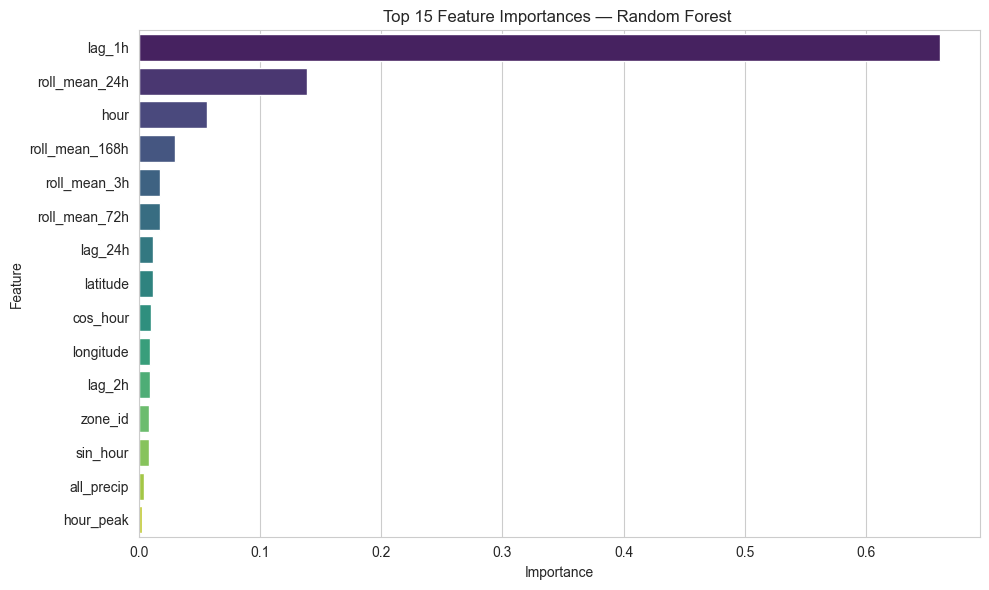

In [ ]:
imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(15), x="Importance", y="Feature", palette="viridis")
plt.title("Top 15 Feature Importances — Random Forest ")
plt.tight_layout()
plt.show()


Biểu đồ dự báo

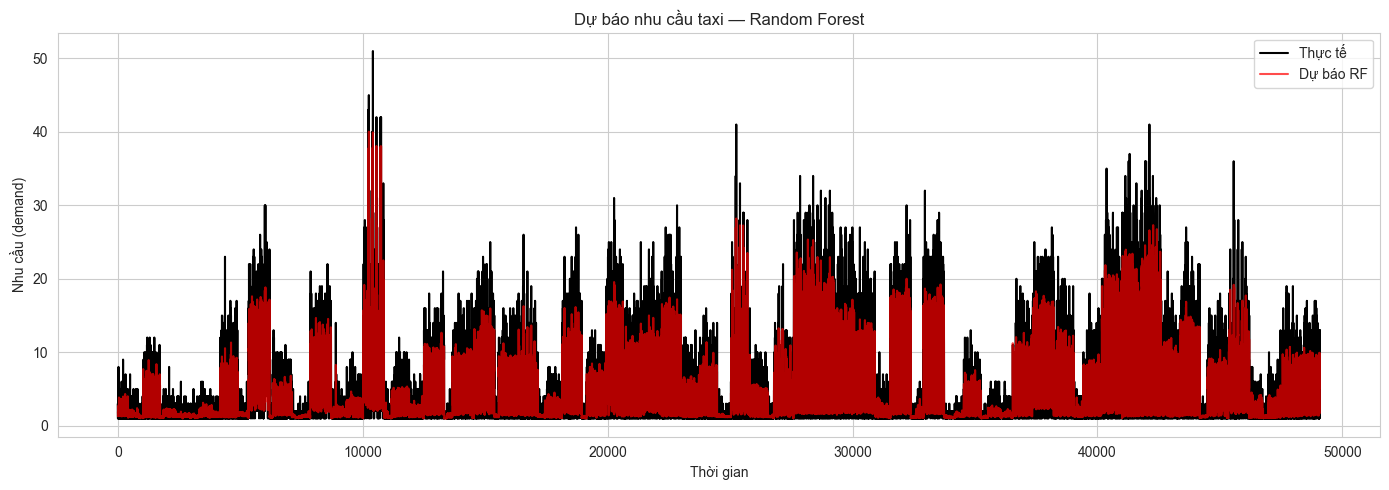

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(y_test_rf.index, y_test_rf, label="Thực tế", color="black")
plt.plot(y_test_rf.index, y_pred_rf, label="Dự báo RF", color="red", alpha=0.7)
plt.title("Dự báo nhu cầu taxi — Random Forest")
plt.xlabel("Thời gian")
plt.ylabel("Nhu cầu (demand)")
plt.legend()
plt.tight_layout()
plt.show()

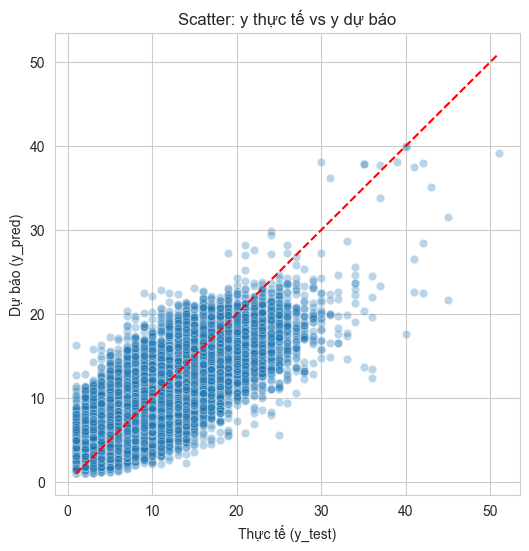

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_rf, y=y_pred_rf, alpha=0.3)
plt.plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], 'r--')
plt.xlabel("Thực tế (y_test)")
plt.ylabel("Dự báo (y_pred)")
plt.title("Scatter: y thực tế vs y dự báo")
plt.show()

## XG BOOST

Chọn siêu tham số bằng Random Search

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X_train_xgb, y_train_xgb = X_train.copy(), y_train.copy()
X_test_xgb,  y_test_xgb  = X_test.copy(),  y_test.copy()

print(f"Train size: {len(X_train_xgb):,} | Test size: {len(X_test_xgb):,}")

Train size: 198,353 | Test size: 49,085


In [ ]:
param_grid_xgb = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.015, 0.02],
    "n_estimators": [500, 700, 900],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [3, 5, 8],
    "gamma": [0, 2, 4],
    "reg_alpha": [0.1, 0.5, 1.0],
    "reg_lambda": [1, 3, 5],
    "max_bin": [256, 512],
    "tree_method": ["hist"]
}

tscv_xgb = TimeSeriesSplit(n_splits=3)

rs_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
    param_distributions=param_grid_xgb,
    scoring="neg_mean_absolute_error",
    cv=tscv_xgb,
    n_iter=15,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Đang chạy Random Search cho XGBoost ")
rs_xgb.fit(X_train_xgb, y_train_xgb)
print("\n Best Params (XGBoost):", rs_xgb.best_params_)


Đang chạy Random Search cho XGBoost 
Fitting 3 folds for each of 15 candidates, totalling 45 fits

 Best Params (XGBoost): {'tree_method': 'hist', 'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 900, 'min_child_weight': 8, 'max_depth': 4, 'max_bin': 256, 'learning_rate': 0.015, 'gamma': 0, 'colsample_bytree': 0.7}


In [ ]:
xgb_best = xgb.XGBRegressor(
    **rs_xgb.best_params_,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42
)

xgb_best.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.015, max_bin=256,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=8, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=900, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred_xgb = xgb_best.predict(X_test_xgb)

def mape_eps(y_true, y_pred, eps=10):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
r2_xgb = r2_score(y_test_xgb, y_pred_xgb)
mape_xgb = mape_eps(y_test_xgb, y_pred_xgb)

print("\n HIỆU NĂNG MÔ HÌNH XGBoost")
print(f"MAE  = {mae_xgb:.2f}")
print(f"RMSE = {rmse_xgb:.2f}")
print(f"R²   = {r2_xgb:.3f}")
print(f"MAPE = {mape_xgb:.2f}%")


 HIỆU NĂNG MÔ HÌNH XGBoost
MAE  = 1.83
RMSE = 2.68
R²   = 0.743
MAPE = 16.15%


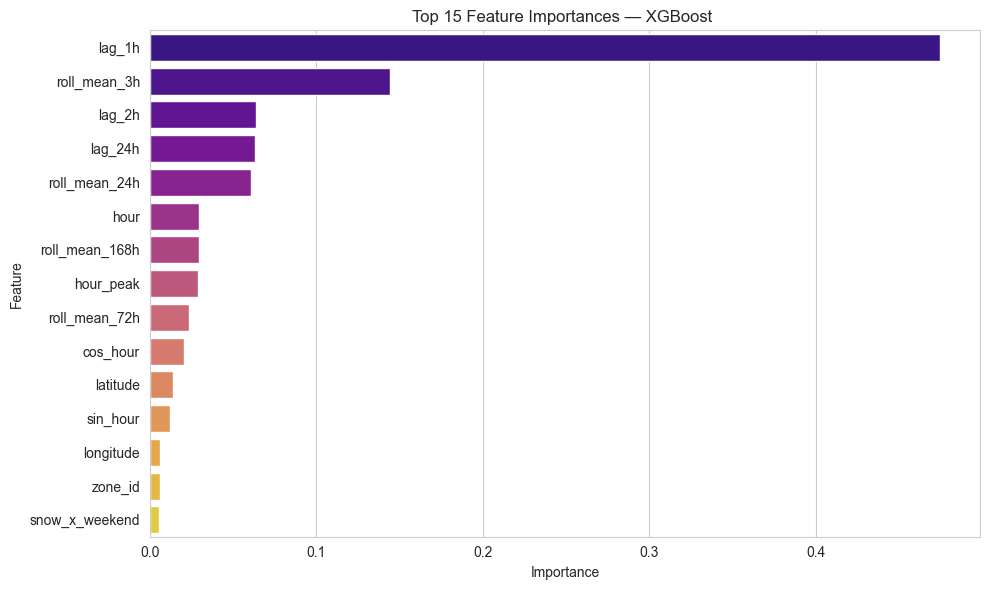

In [ ]:
imp_df_xgb = pd.DataFrame({
    "Feature": X_train_xgb.columns,
    "Importance": xgb_best.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df_xgb.head(15), x="Importance", y="Feature", palette="plasma")
plt.title("Top 15 Feature Importances — XGBoost ")
plt.tight_layout()
plt.show()


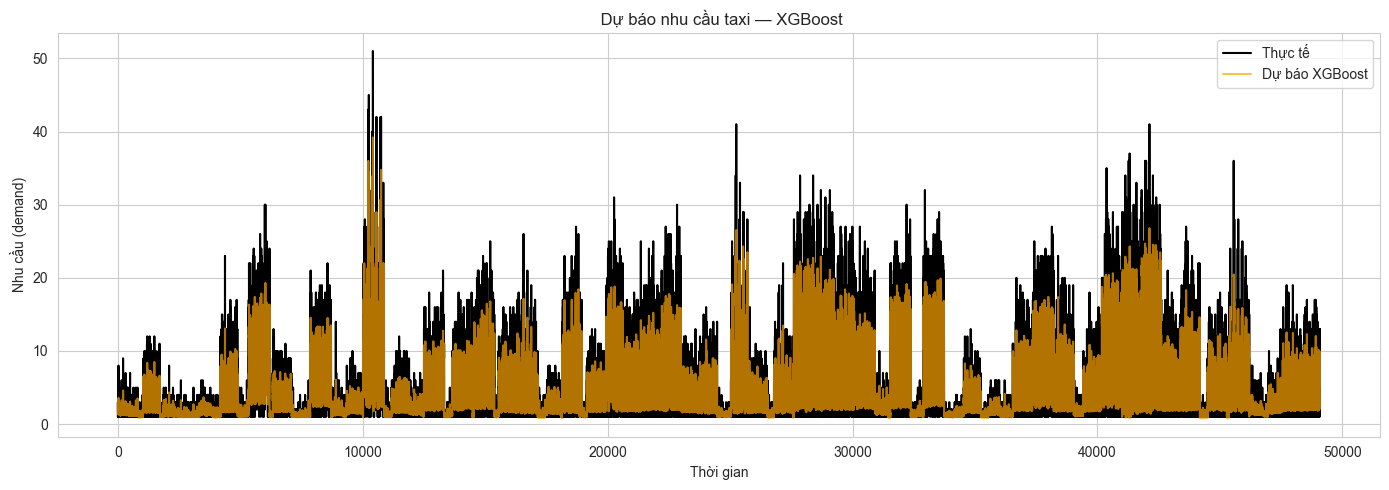

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(y_test_xgb.index, y_test_xgb, label="Thực tế", color="black")
plt.plot(y_test_xgb.index, y_pred_xgb, label="Dự báo XGBoost", color="orange", alpha=0.7)
plt.title(" Dự báo nhu cầu taxi — XGBoost" )
plt.xlabel("Thời gian"); plt.ylabel("Nhu cầu (demand)")
plt.legend(); plt.tight_layout(); plt.show()

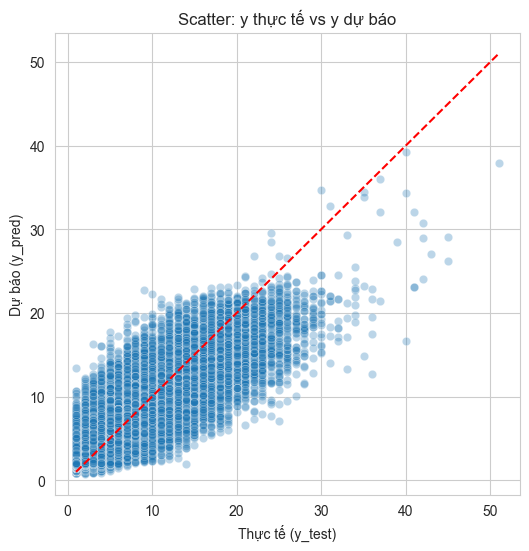

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test_xgb, y=y_pred_xgb, alpha=0.3)
plt.plot([y_test_xgb.min(), y_test_xgb.max()], [y_test_xgb.min(), y_test_xgb.max()], 'r--')
plt.xlabel("Thực tế (y_test)")
plt.ylabel("Dự báo (y_pred)")
plt.title("Scatter: y thực tế vs y dự báo")
plt.show()

## SO SÁNH MÔ HÌNH

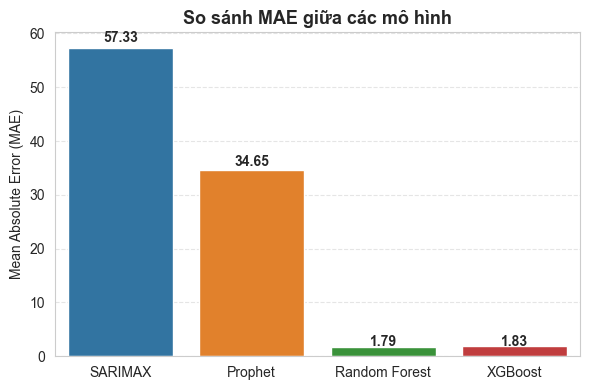

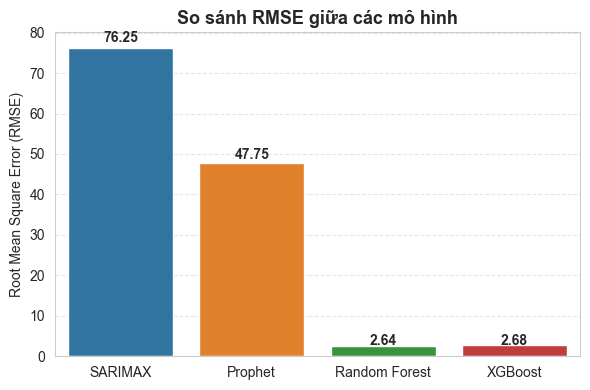

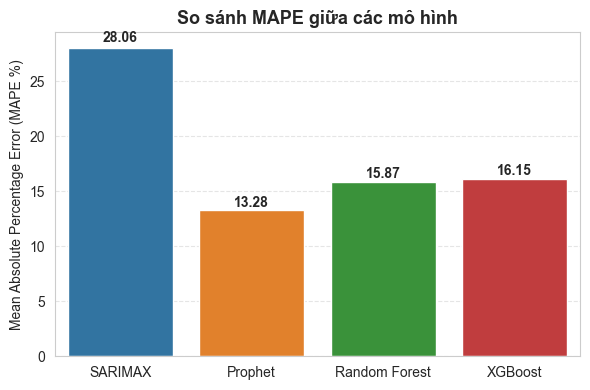

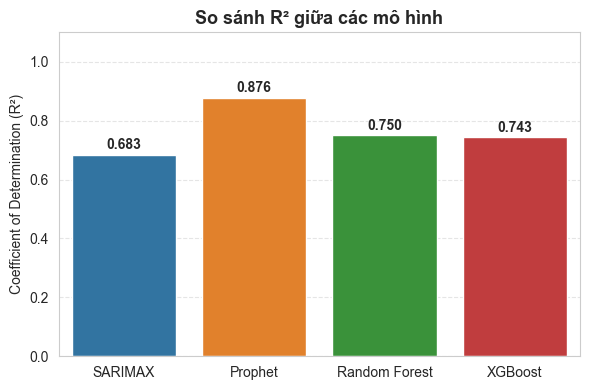

In [ ]:
results = {
    "Model": ["SARIMAX", "Prophet", "Random Forest", "XGBoost"],
    "MAE":   [57.33, 34.65, 1.79, 1.83],
    "RMSE":  [76.25, 47.75, 2.64, 2.68],
    "R²":    [0.6833, 0.876, 0.750, 0.743],
    "MAPE":  [28.06, 13.28, 15.87, 16.15]
}

df = pd.DataFrame(results)

def plot_bar(metric, title, ylabel, color_palette):
    plt.figure(figsize=(6,4))
    ax = sns.barplot(data=df, x="Model", y=metric, palette=color_palette)
    plt.title(title, fontsize=13, weight='bold')
    plt.ylabel(ylabel)
    plt.xlabel("")

    for i, val in enumerate(df[metric]):
        ax.text(i, val + (0.02 * val), f"{val:.2f}", ha='center', fontsize=10, fontweight='bold')

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

plot_bar("MAE",  "So sánh MAE giữa các mô hình",  "Mean Absolute Error (MAE)", colors)
plot_bar("RMSE", "So sánh RMSE giữa các mô hình", "Root Mean Square Error (RMSE)", colors)
plot_bar("MAPE", "So sánh MAPE giữa các mô hình", "Mean Absolute Percentage Error (MAPE %)", colors)

plt.figure(figsize=(6,4))
ax = sns.barplot(data=df, x="Model", y="R²", palette=colors)
plt.title("So sánh R² giữa các mô hình", fontsize=13, weight='bold')
plt.ylabel("Coefficient of Determination (R²)")
plt.xlabel("")

for i, val in enumerate(df["R²"]):
    ax.text(i, val + 0.02, f"{val:.3f}", ha='center', fontsize=10, fontweight='bold')

plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Xuất mô hình tốt nhất để deploy

In [ ]:
df = demand_ml.copy().sort_values(["pickup_zone", "pickup_hour"]).reset_index(drop=True)

df["lag_1h"]  = df.groupby("pickup_zone")["demand_1"].shift(1)
df["lag_2h"]  = df.groupby("pickup_zone")["demand_1"].shift(2)
df["lag_24h"] = df.groupby("pickup_zone")["demand_1"].shift(24)

df["roll_mean_3h"]   = df.groupby("pickup_zone")["demand_1"].shift(1).rolling(3).mean()
df["roll_mean_24h"]  = df.groupby("pickup_zone")["demand_1"].shift(1).rolling(24).mean()
df["roll_mean_72h"]  = df.groupby("pickup_zone")["demand_1"].shift(1).rolling(72).mean()
df["roll_mean_168h"] = df.groupby("pickup_zone")["demand_1"].shift(1).rolling(168).mean()

lag_cols = ["lag_1h","lag_2h","lag_24h",
            "roll_mean_3h","roll_mean_24h","roll_mean_72h","roll_mean_168h"]
df[lag_cols] = df[lag_cols].fillna(0).astype("float32")

df["hour_peak"] = df["hour"].isin([7,8,9,17,18,19]).astype("int8")
df["rain_x_peak"] = df["all_precip"] * df["hour_peak"]
df["snow_x_weekend"] = df["has_snow"] * df["is_weekend"]
df["blizzard_x_precip"] = df["is_blizzard"] * df["all_precip"]

features = [
    "zone_id", "borough_id",
    "hour", "sin_hour", "cos_hour",
    "all_precip", "has_rain", "has_snow",
    "is_blizzard", "is_blizzard_leadlag",
    "lag_1h","lag_2h","lag_24h",
    "roll_mean_3h","roll_mean_24h","roll_mean_72h","roll_mean_168h",
    "longitude","latitude",
    "hour_peak","rain_x_peak","snow_x_weekend","blizzard_x_precip"
]

X = df[features].astype("float32")

y_pred_all = best_model.predict(X)

y_pred_all = np.maximum(0, np.round(y_pred_all)).astype(int)

rf_results = pd.DataFrame({
    "pickup_hour": df["pickup_hour"],
    "pickup_zone": df["pickup_zone"],
    "demand_pred": y_pred_all
})

rf_results["pickup_hour"] = pd.to_datetime(rf_results["pickup_hour"], errors="coerce")
rf_results = rf_results[rf_results["pickup_hour"].dt.month <= 6].copy()

rf_results.to_csv("taxi_demand_predictions_2016.csv", index=False, encoding="utf-8-sig")

print("Đã xuất file Random Forest dự báo 6 tháng đầu 2016 (đã làm tròn).")
print(f" {len(rf_results):,} dòng | {rf_results['pickup_hour'].min()} → {rf_results['pickup_hour'].max()}")


Đã xuất file Random Forest dự báo 6 tháng đầu 2016 (đã làm tròn).
 247,859 dòng | 2016-01-01 00:00:00 → 2016-06-30 23:00:00
